# 3-DOF Lander Model

Síntese de Sistema de Controle para Modelo de 3DOF de Lander

Modelagem de Planetary Lander em 3 graus de liberdade, sob o objetivo de controlar a atitude e altitude do sistema por meio de entradas de controle de empuxo, sob o objetivo de desenvolver um protótipo de Self Landing Module.

Entradas de Controle - $T$ (Empuxo Central do Foguete)  e $\beta $ (TVC)

Entrada de Perturbação - $w$ (Vento Horizontal)


### Instalação dos Pacotes Necessários

In [1]:
#%pip install numpy
#%pip install scipy
#%pip install sympy
%pip install tbcontrol
#%pip install seaborn
%pip install control


import numpy as np
from scipy.integrate import solve_ivp
import sympy as sp
from sympy.abc import s
from sympy.physics.control.lti import TransferFunction
import control as ct
from tbcontrol.symbolic import routh
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from seaborn import color_palette
colors = color_palette()

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from sympy.physics.control.control_plots import pole_zero_plot

## Definição do Modelo

### Modelagem matemática - equação de movimento do veículo

Equacionamento físico do sistema utilizando o Teorema da Resultante e o TQMA, baseando-se no método de Newton-Euler

Definição de variáveis e funções simbólicas (pacote `sympy`):

In [3]:

m, g, Jg, ρ, A_m, A_f, Cl, D_Cp, α, φ, D_n, β = sp.symbols(
    'm, g, Jg, ρ, A_m, A_f, Cl, D_Cp, α, φ, D_n, β', positive=True)
t = sp.symbols('t')
w = sp.symbols('w')
θ = sp.Function('θ')(t)
x = sp.Function('x')(t)
y = sp.Function('y')(t)
Cd = sp.Function('Cd')(t)
T = sp.Function('T')(t)
s = sp.symbols('s')
T_lat = sp.Function('T_lat')(t)

Cinemática - Velocidade Relativa ao Vento

In [4]:
vx_vento = x.diff(t) - w
vy_vento = y.diff(t)
print(vx_vento)
print(vy_vento)

-w + Derivative(x(t), t)
Derivative(y(t), t)


Ângulo de Velocidade Relativa ($φ$) e de Ataque ($α$)

In [5]:
φ = sp.pi/2 - sp.atan(vx_vento/vy_vento)
α = φ - θ

Força de Arrasto

In [6]:
D = Cd * sp.Rational(1, 2)* ρ * A_f * (vx_vento**2 + vy_vento**2)
D

A_f*ρ*((-w + Derivative(x(t), t))**2 + Derivative(y(t), t)**2)*Cd(t)/2

#### Equações Diferenciais Governantes

$T$: Entrada de Controle: Empuxo Central, provido por motor híbrido/líquido com devida regulação de injeção

$\Beta$: Entrada de Controle: Gimble do Nozzle 

$θ$: Ângulo de arfagem do lander

$D_{Cp}$: Distância entre CM e CP

$D_n$: Distância entre CM e Nozzle

In [7]:
from operator import eq
eqx = m*x.diff(t, 2)  + D*sp.cos(φ) - T*sp.cos(θ)*sp.cos(β) -T*sp.sin(β)*sp.cos(θ + sp.pi/2)
eqy = m*y.diff(t, 2)  + D*sp.sin(φ) + m*g - T*sp.sin(β)*sp.sin(θ + sp.pi/2)  - T*sp.sin(θ)*sp.cos(β)
eqθ = Jg*θ.diff(t, 2)  + D*D_Cp*sp.sin(α) - T*sp.sin(β)*D_n


In [8]:
d2x_s = sp.solve(eqx, x.diff(t, 2))[0]
d2x_s = d2x_s.subs({ρ: 1.225}).simplify() #Modelo de atmosfera ISA aplicado

In [9]:
d2y_s = sp.solve(eqy, y.diff(t, 2))[0]
d2y_s = d2y_s.subs({ρ:1.225}).simplify()

In [10]:
d2θ_s = sp.solve(eqθ, θ.diff(t, 2))[0]
d2θ_s = d2θ_s.subs({ρ: 1.225 }).simplify()

In [11]:
d2x_s

(0.6125*A_f*w*sqrt((w**2 - 2*w*Derivative(x(t), t) + Derivative(x(t), t)**2 + Derivative(y(t), t)**2)/Derivative(y(t), t)**2)*Cd(t)*Derivative(y(t), t) - 0.6125*A_f*sqrt((w**2 - 2*w*Derivative(x(t), t) + Derivative(x(t), t)**2 + Derivative(y(t), t)**2)/Derivative(y(t), t)**2)*Cd(t)*Derivative(x(t), t)*Derivative(y(t), t) + T(t)*cos(β + θ(t)))/m

### Linearização do Modelo

Imposição da Condição de Equilíbrio (Voo Vertical com Aceleração e Velocidade vertical em regime controlado) e dados dinâmicos do cad preliminar do lander, para conhecimento de Empuxo de equilíbrio


In [12]:
# Define velocidade de interesse para linearização
V0 = 10  # Velocidade de interesse (m/s)

In [13]:
eqy

A_f*ρ*((-w + Derivative(x(t), t))**2 + Derivative(y(t), t)**2)*Cd(t)/(2*sqrt((-w + Derivative(x(t), t))**2/Derivative(y(t), t)**2 + 1)) + g*m + m*Derivative(y(t), (t, 2)) - T(t)*sin(β)*cos(θ(t)) - T(t)*sin(θ(t))*cos(β)

In [14]:
eqxs = eqx.subs({ θ: sp.pi/2, β: 0, x.diff(t): 0,  θ.diff(t): 0,y.diff(t): V0, x.diff(t,2): 0,  Cd: 0.35, w: 0, m: 25.733, Jg: 7.59767, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 }) #T: 558.26,
eqys = eqy.subs({ θ: sp.pi/2, β: 0, x.diff(t): 0, θ.diff(t): 0,y.diff(t): V0, x.diff(t,2): 0,  Cd: 0.35, w: 0, m: 25.733, Jg: 7.59767, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 })
eqθs = eqθ.subs({ D_n: 0.818, θ:sp.pi/2, β: 0, x.diff(t): 0,y.diff(t): V0,  θ.diff(t): 0,   Cd: 0.35, w: 0, m: 25.733, Jg: 7.59767, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 })


In [15]:
eqys

-T(t) + 25.733*Derivative(10, t) + 252.8909175

In [16]:
T_eq = sp.solve(eqys, T) #Calculo do T para o equilíbrio em y
print("Empuxo Central (T_eq): ", T_eq)

Empuxo Central (T_eq):  [252.890917500000]


Equações de movimento linearizadas, em termos das variáveis de estado incrementais $\mathbf{x} = (y, \theta,\dot x, \dot y, \dot \theta)$, expressa na forma de espaço de estados com as entradas $dT, dT_{lat}, dw$ representando variações incrementais ao redor da condição de equilíbrio:
$\dfrac{\text{d} \mathbf{x}}{\text{d} t} = \mathbf{A} \mathbf{x} + \mathbf{B_1} \mathbf{u_1} + \mathbf{B_2} \mathbf{u_2} + \mathbf{E} \mathbf{w}$

Foram utilizadas as condições de equilíbrio definidas anteriormente, caracterizando uma linearização ao redor de uma trajetória, o que gera um sistema linear com dependência no tempo. Porém, para primeira análise o sistema foi tomado em $t=0$, facilitando a abordagem pelos métodos SLIT

In [17]:
dxdt = sp.Matrix([ y.diff(t), θ.diff(t), d2x_s, d2y_s, d2θ_s])
dxdt

Matrix([
[                                                                                                                                                                                                                                                                                                                                       Derivative(y(t), t)],
[                                                                                                                                                                                                                                                                                                                                       Derivative(θ(t), t)],
[(0.6125*A_f*w*sqrt((w**2 - 2*w*Derivative(x(t), t) + Derivative(x(t), t)**2 + Derivative(y(t), t)**2)/Derivative(y(t), t)**2)*Cd(t)*Derivative(y(t), t) - 0.6125*A_f*sqrt((w**2 - 2*w*Derivative(x(t), t) + Derivative(x(t), t)**2 + Derivative(y(t), t)**2)/Derivative(y(t), t)**2)*Cd(t)*Derivat

In [18]:
A = dxdt.jacobian(([y, θ, x.diff(t), y.diff(t), θ.diff(t)])).subs({y: 0 + V0*t, T: T_eq[0], θ: sp.pi/2, D_n: 0.818, T_lat: 0, β: 0, x.diff(t): 0, y.diff(t):  V0, Cd: 0.35, w: 0, m: 25.733, Jg: 7.59767, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 })
A

Matrix([
[0,                  0,                    0,                    1, 0],
[0,                  0,                    0,                    0, 1],
[0,  -9.82749455951502, -0.00174945595150196,                    0, 0],
[0,                  0,                    0, -0.00349891190300392, 0],
[0, 0.0225755313800152,  0.00225755313800152,                    0, 0]])

In [19]:
B1 = dxdt.diff(T).subs({y: 0 + V0*t, T: T_eq[0], θ: sp.pi/2, D_n: 0.818, T_lat: 0, β: 0, x.diff(t): 0, y.diff(t): 10, Cd: 0.35, w: 0, m: 25.733, Jg: 7.59767, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 })
B1

Matrix([
[                 0],
[                 0],
[                 0],
[0.0388606070026814],
[                 0]])

In [20]:
B2 = dxdt.diff(β).subs({y: 0 + V0*t, T: T_eq[0], θ: sp.pi/2, D_n: 0.818, T_lat: 0, β: 0, x.diff(t): 0, y.diff(t): 10, Cd: 0.35, w: 0, m: 25.733, Jg: 7.59767, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 })
B2

Matrix([
[                0],
[                0],
[-9.82749455951502],
[                0],
[ 27.2273960984091]])

In [21]:
E = dxdt.diff(w).subs({y: 0 + V0*t, T: T_eq[0], θ: sp.pi/2, D_n: 1, T_lat: 0, β: 0, x.diff(t): 0, y.diff(t): 10, Cd: 0.35, w: 0, m: 27, Jg: 12.622, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 })
E

Matrix([
[                   0],
[                   0],
[ 0.00166736111111111],
[                   0],
[-0.00135890855252733]])

### Criação do Espaço de Estados na Biblioteca Control

Aqui foi definido o vetor de observações do sistema como sendo respectivamente, a observação da altitude do veículo e sua atitude em relação à horizontal. Também foram unidos as duas entradas de controle em vetor único para posterior uso da biblioteca _Control_

In [22]:
O1 = sp.Matrix([[1],[0],[0],[0],[0]])
O2 = sp.Matrix([[0],[1],[0],[0],[0]])
O = sp.Matrix.hstack(O1, O2)
B = sp.Matrix.hstack(B1, B2)

Para permitir a análise direta do sistema foram definidas as matrizes A e E de estado inicial, permitindo avaliar o sistema como SLIT, no instante inicial

In [23]:
lander = ct.ss(A, B, O.transpose(), sp.zeros(2, 2))
print(lander)

<StateSpace>: sys[0]
Inputs (2): ['u[0]', 'u[1]']
Outputs (2): ['y[0]', 'y[1]']
States (5): ['x[0]', 'x[1]', 'x[2]', 'x[3]', 'x[4]']

A = [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
       0.00000000e+00]
     [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
       1.00000000e+00]
     [ 0.00000000e+00 -9.82749456e+00 -1.74945595e-03  0.00000000e+00
       0.00000000e+00]
     [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -3.49891190e-03
       0.00000000e+00]
     [ 0.00000000e+00  2.25755314e-02  2.25755314e-03  0.00000000e+00
       0.00000000e+00]]

B = [[ 0.          0.        ]
     [ 0.          0.        ]
     [ 0.         -9.82749456]
     [ 0.03886061  0.        ]
     [ 0.         27.2273961 ]]

C = [[1. 0. 0. 0. 0.]
     [0. 1. 0. 0. 0.]]

D = [[0. 0.]
     [0. 0.]]


In [24]:
lander_Pert = ct.ss(A, E, O.transpose(), sp.zeros(2, 1)) #sistema sob ação de perrturbações externas (vento)
print(lander_Pert)

<StateSpace>: sys[1]
Inputs (1): ['u[0]']
Outputs (2): ['y[0]', 'y[1]']
States (5): ['x[0]', 'x[1]', 'x[2]', 'x[3]', 'x[4]']

A = [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
       0.00000000e+00]
     [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
       1.00000000e+00]
     [ 0.00000000e+00 -9.82749456e+00 -1.74945595e-03  0.00000000e+00
       0.00000000e+00]
     [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -3.49891190e-03
       0.00000000e+00]
     [ 0.00000000e+00  2.25755314e-02  2.25755314e-03  0.00000000e+00
       0.00000000e+00]]

B = [[ 0.        ]
     [ 0.        ]
     [ 0.00166736]
     [ 0.        ]
     [-0.00135891]]

C = [[1. 0. 0. 0. 0.]
     [0. 1. 0. 0. 0.]]

D = [[0.]
     [0.]]


## Funções de Transferência do Sistema
Desenvolvimento dos Equacionamentos Necessários para definir as funções de transferência para as entradas $T, \beta, w$, para os vetores os vetores de observação $o(t) = θ(t)$ e $o(t) = y(t)$ obtendo:

$G1 = T(s)/T(s)$

$G2 = Θ(s)/B(s)$

$G3 = Θ(s)/W(s)$

In [25]:
G1frac = sp.fraction((O1.transpose() * (s*sp.eye(5) - A).inv() * B1)[0].simplify())
G2frac = sp.fraction((O2.transpose() * (s*sp.eye(5) - A).inv() * B2)[0].simplify())
G3frac = sp.fraction((O2.transpose() * (s*sp.eye(5) - A).inv() * E)[0].simplify())
G1 = TransferFunction(G1frac[0], G1frac[1], s)
G2 = TransferFunction(G2frac[0], G2frac[1], s)
G3 = TransferFunction(G3frac[0], G3frac[1], s)

In [26]:
print("Função de Transferência do Controle de Altitude (G1):")
G1.simplify()

Função de Transferência do Controle de Altitude (G1):


TransferFunction(0.0388606070026814*s**3 + 6.79849201998198e-5*s**2 - 0.000877298852835472*s + 0.000860630174631598, s*(1.0*s**4 + 0.00524836785450589*s**3 - 0.0225694101877627*s**2 + 0.0220676064883327*s + 7.74889893483925e-5), s)

In [27]:
print("Função de Transferência do Controle de Atitude (G2):")
G2.simplify()

Função de Transferência do Controle de Atitude (G2):


TransferFunction(27.2273960984091*s**2 + 0.120713299263263*s + 8.90369475369213e-5, 1.0*s**4 + 0.00524836785450589*s**3 - 0.0225694101877627*s**2 + 0.0220676064883327*s + 7.74889893483925e-5, s)

In [28]:
print("Função de Transferência da Altitude e Atitude à Perturbação (G3):")
G3.simplify()

Função de Transferência da Altitude e Atitude à Perturbação (G3):


TransferFunction(-0.00135890855252733*s**2 - 3.36789565572699e-6*s + 4.8523108092505e-9, 1.0*s**4 + 0.00524836785450589*s**3 - 0.0225694101877627*s**2 + 0.0220676064883327*s + 7.74889893483925e-5, s)

In [29]:
def poly_to_coeffs(poly_expr, symbol):
    poly = sp.poly(poly_expr, symbol)
    coeffs = poly.all_coeffs()
    return [float(c) for c in coeffs]

## Análise de estabilidade do modelo linearizado

A análise baseada na verificação da posição dos polos do sistema indica instabilidade inerente do sistema, devido a presença de polos com parte real negativa. Tais instabilidades estão presentes nos polos relativos a posição vertical e ao angulo de atitude do foguete, com este último possuindo forte dependência da velocidade $y$ do foguete, uma vez que o controle passivo de atitude via momento restaurador das aletas depende do valor da força de lift.

In [30]:
lander.poles()

array([-0.30818272+0.j        ,  0.15321663+0.21996947j,
        0.15321663-0.21996947j,  0.        +0.j        ,
       -0.00349891+0.j        ])

Polinômio característico da matriz ${A}$:

In [31]:
p = A.charpoly('s')
p

PurePoly(1.0*s**5 + 0.00524836785450589*s**4 - 0.0225694101877627*s**3 + 0.0220676064883327*s**2 + 7.74889893483925e-5*s, s, domain='RR')

Tabela de Routh do polinômio caracterísitico:

In [32]:
RH_t =routh(p)
RH_t

Matrix([
[                1.0, -0.0225694101877627, 7.74889893483925e-5],
[0.00524836785450589,  0.0220676064883327,                   0],
[  -4.22723019237493, 7.74889893483925e-5,                   0],
[ 0.0220677026957078,                   0,                   0],
[7.74889893483925e-5,                   0,                   0],
[                  0,                   0,                   0]])

In [33]:
sp.solve(p, s)

[-0.308182715418989,
 -0.00349891190300393,
 0.0,
 0.153216629733743 - 0.219969468314126*I,
 0.153216629733743 + 0.219969468314126*I]

### Polos e Zeros via Control

<TransferFunction>: sys[4]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      0.03886
  ----------------
  s^2 + 0.003499 s


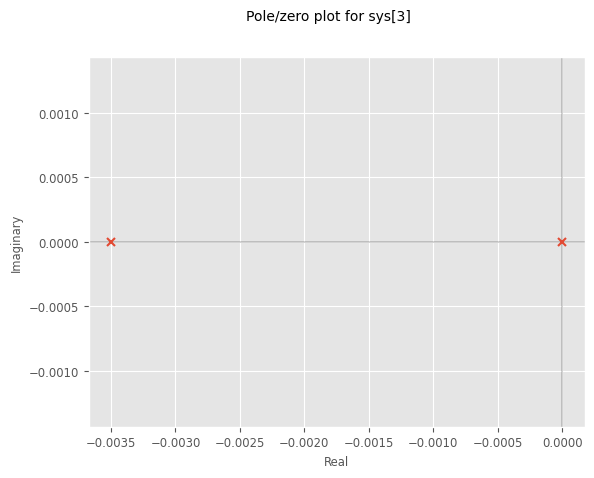

In [34]:
T1 = ct.tf(poly_to_coeffs(G1frac[0], s), poly_to_coeffs(G1frac[1], s)).minreal()
ct.pole_zero_plot(T1)
print(T1.minreal())

<TransferFunction>: sys[7]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             27.23 s + 0.02545
  ----------------------------------------
  s^3 + 0.001749 s^2 - 0.02258 s + 0.02215


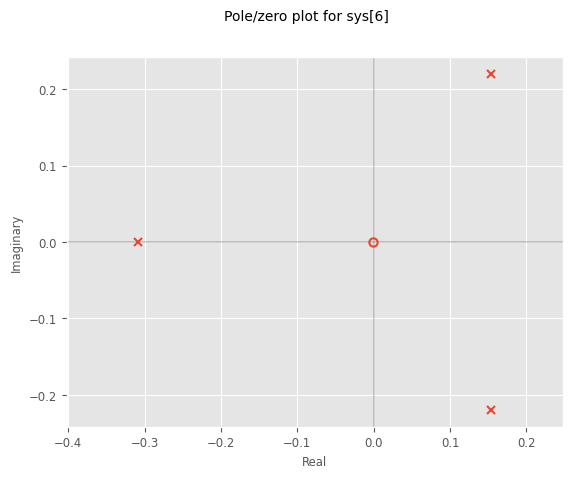

In [35]:
T2 = ct.tf(poly_to_coeffs(G2frac[0], s), poly_to_coeffs(G2frac[1], s)).minreal()
ct.pole_zero_plot(T2)
print(T2.minreal())

<TransferFunction>: sys[10]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          -0.001359 s + 1.387e-06
  ----------------------------------------
  s^3 + 0.001749 s^2 - 0.02258 s + 0.02215


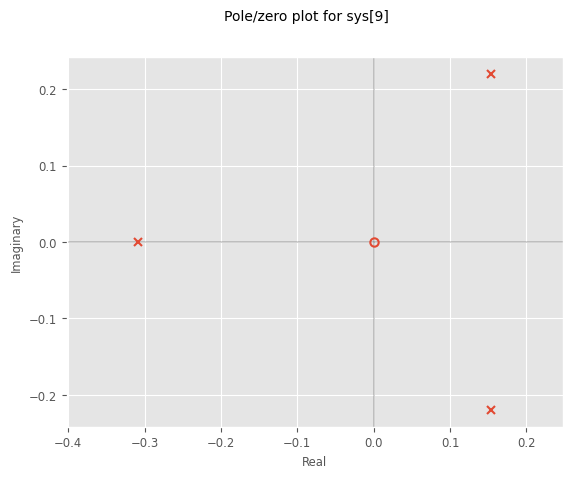

In [36]:
T3 = ct.tf(poly_to_coeffs(G3frac[0], s), poly_to_coeffs(G3frac[1], s)).minreal()
ct.pole_zero_plot(T3)
print(T3.minreal())

## Análise no Domínio da Frequência
Desenvolvimento e análise dos Diagramas de Bode do Sistema

c:\Users\felip\anaconda3\Lib\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


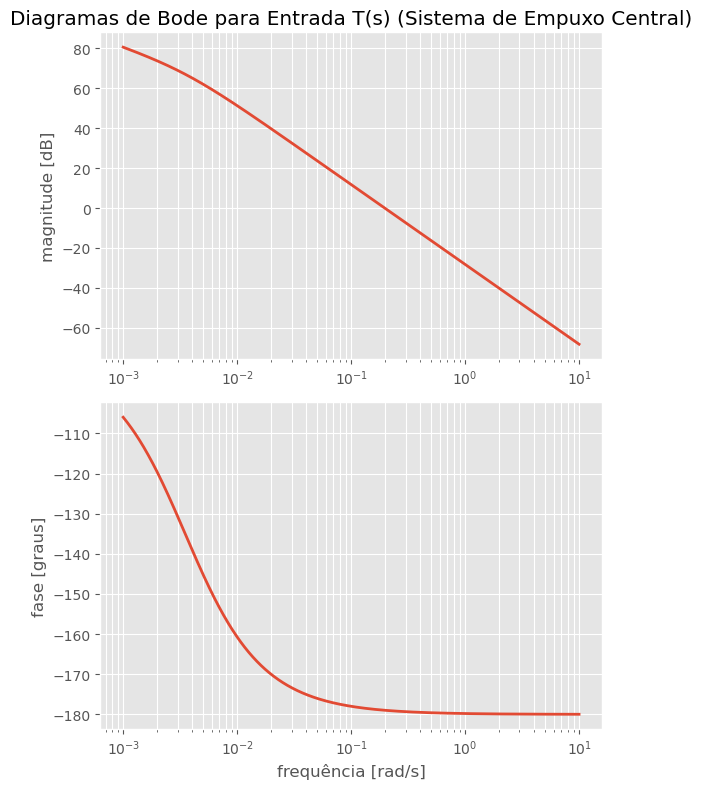

In [37]:
plt.figure(figsize=(6, 8))

mag, phase, omega = ct.bode(T1, omega_limits=(0.001, 10), plot=False)

plt.subplot(2, 1, 1)
plt.title("Diagramas de Bode para Entrada T(s) (Sistema de Empuxo Central)")
plt.semilogx(omega, 20 * np.log10(mag), linewidth=2)
plt.ylabel("magnitude [dB]")
plt.grid(True, which="both")

plt.subplot(2, 1, 2)
plt.semilogx(omega, np.rad2deg(phase), linewidth=2)
plt.ylabel("fase [graus]")
plt.xlabel("frequência [rad/s]")
plt.grid(True, which="both")

plt.tight_layout()
plt.show()


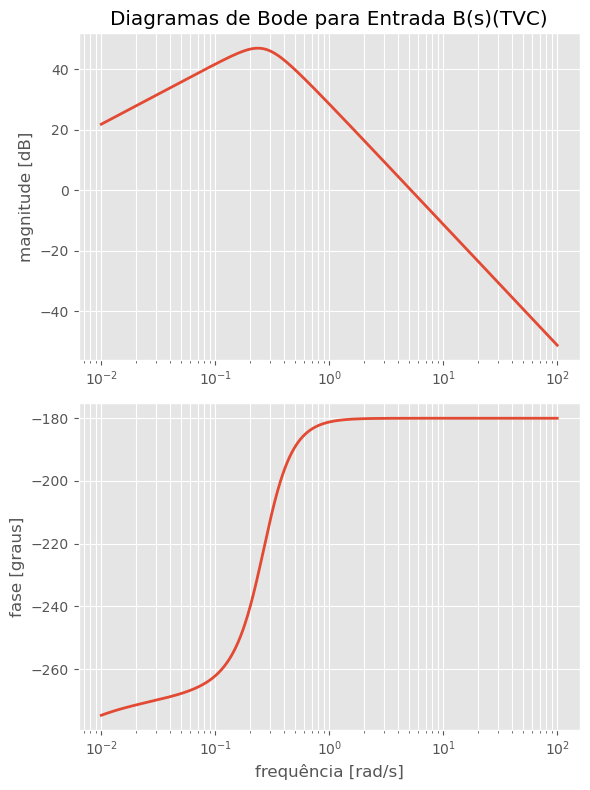

In [38]:
plt.figure(figsize=(6, 8))

mag1, phase1, omega1 = ct.bode(T2, omega_limits=(0.01, 100), plot=False)

plt.subplot(2, 1, 1)
plt.title("Diagramas de Bode para Entrada B(s)(TVC)")
plt.semilogx(omega1, 20 * np.log10(mag1), linewidth=2)
plt.ylabel("magnitude [dB]")
plt.grid(True, which="both")

plt.subplot(2, 1, 2)
plt.semilogx(omega1, np.rad2deg(phase1), linewidth=2)
plt.ylabel("fase [graus]")
plt.xlabel("frequência [rad/s]")
plt.grid(True, which="both")

plt.tight_layout()
plt.show()

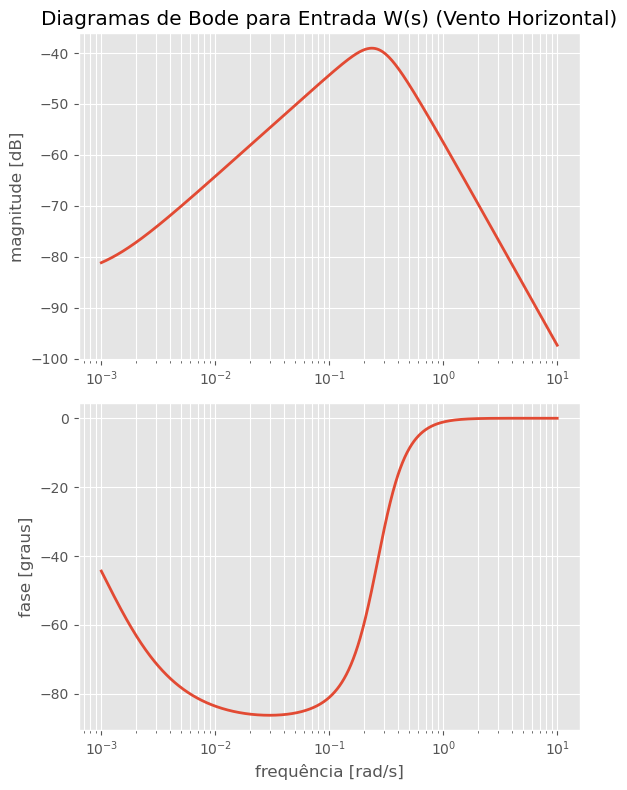

In [39]:
plt.figure(figsize=(6, 8))

mag, phase, omega = ct.bode(T3, omega_limits=(0.001, 10), plot=False)

plt.subplot(2, 1, 1)
plt.title("Diagramas de Bode para Entrada W(s) (Vento Horizontal)")
plt.semilogx(omega, 20 * np.log10(mag), linewidth=2)
plt.ylabel("magnitude [dB]")
plt.grid(True, which="both")

plt.subplot(2, 1, 2)
plt.semilogx(omega, np.rad2deg(phase), linewidth=2)
plt.ylabel("fase [graus]")
plt.xlabel("frequência [rad/s]")
plt.grid(True, which="both")

plt.tight_layout()
plt.show()

O diagrama de Bode para a entrada $T(s)$ e saída $y(s)$ indica comportamento característico de primeira ordem, o que é esperado para uma entrada do tipo força e saída posicional, considerando o efeito integrador dessa variável com ganhos elevados em baixas frequências e baixo ganho para altas frequências.

O segundo diagrama, relativo a entrada $\beta(s)$ e saída $Θ(s)$, apresenta comportamento clássico de segunda ordem, o que é esperado para uma saída angular à uma entrada de torque, considerando principalmente frequências naturais que podem ser excitadas. Além disso, destaca-se que o amortecimento do sistema é dependente da velocidade à qual o sistema é linearizado.

Em altas frequências $\frac{Θ(s)}{E(s)}$ apresentou um comportamento de segunda ordem, esperado pelo fato de, próximo a frequência natural, a velocidade do vento promove grandes oscilações do foguete ao redor de seu eixo, devido a um grande acoplamento de equacionamentos.

## Análise No Tempo Para Entradas Padrão

Resposta no Tempo para entradas Padrão para $G_1(s)$

In [40]:
stepG1 = ct.step_response(T1, np.linspace(0, 30, 5000))
impulseG1 = ct.impulse_response(T1, np.linspace(0, 30, 5000))
time_vector = np.linspace(0, 30, 5000)
ramp_input = time_vector
rampG1 = ct.forced_response(T1, time_vector, ramp_input)

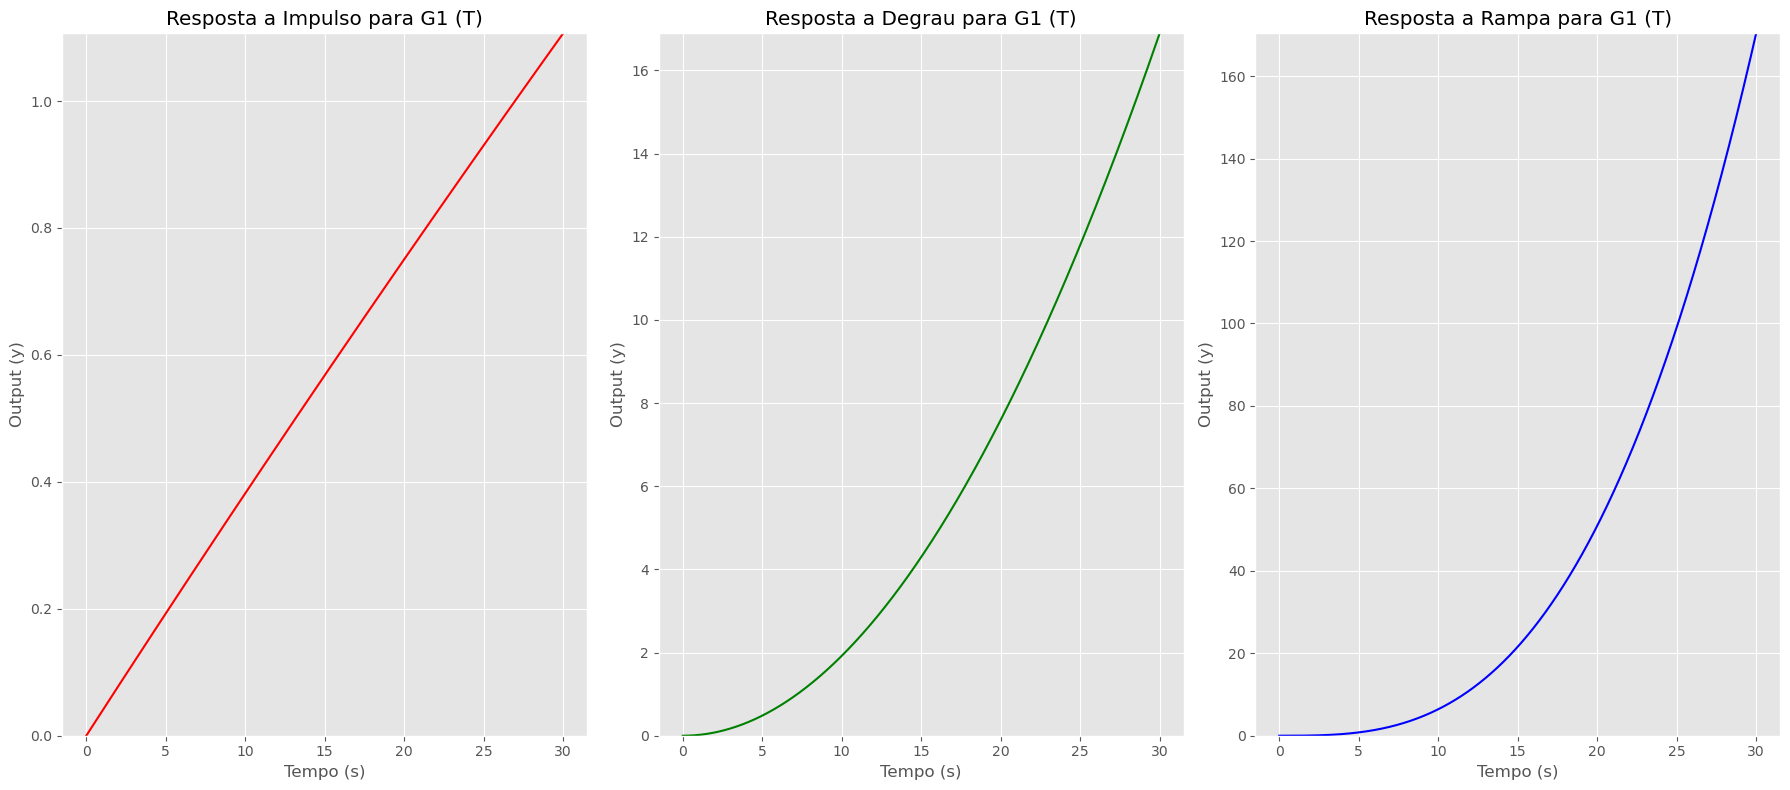

In [41]:
plt.figure(figsize=(18, 8))

# Calculate global min and max for y-axis across all responses
all_outputs = np.concatenate([rampG1.outputs, impulseG1.outputs, stepG1.outputs])
y_min = -25
y_max = np.max(all_outputs)

plt.subplot(1, 3, 1)
plt.plot(impulseG1.time, impulseG1.outputs, color='red')
plt.title("Resposta a Impulso para G1 (T)")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (y)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True) # Apply global y-limits

plt.subplot(1, 3, 2)
plt.plot(stepG1.time, stepG1.outputs, color='green')
plt.title("Resposta a Degrau para G1 (T)")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (y)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True) # Apply global y-limits

plt.subplot(1, 3, 3)
plt.plot(rampG1.time, rampG1.outputs, color='blue')
plt.title("Resposta a Rampa para G1 (T)")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (y)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True) # Apply global y-limits

plt.tight_layout()
plt.show()

Resposta no Tempo para entradas Padrão em $G_2(s)$

In [42]:
stepG2 = ct.step_response(T2, np.linspace(0, 30, 500))
impulseG2 = ct.impulse_response(T2, np.linspace(0, 30, 500))
time_vector = np.linspace(0, 30, 500)
ramp_input = time_vector
rampG2 = ct.forced_response(T2, time_vector, ramp_input)

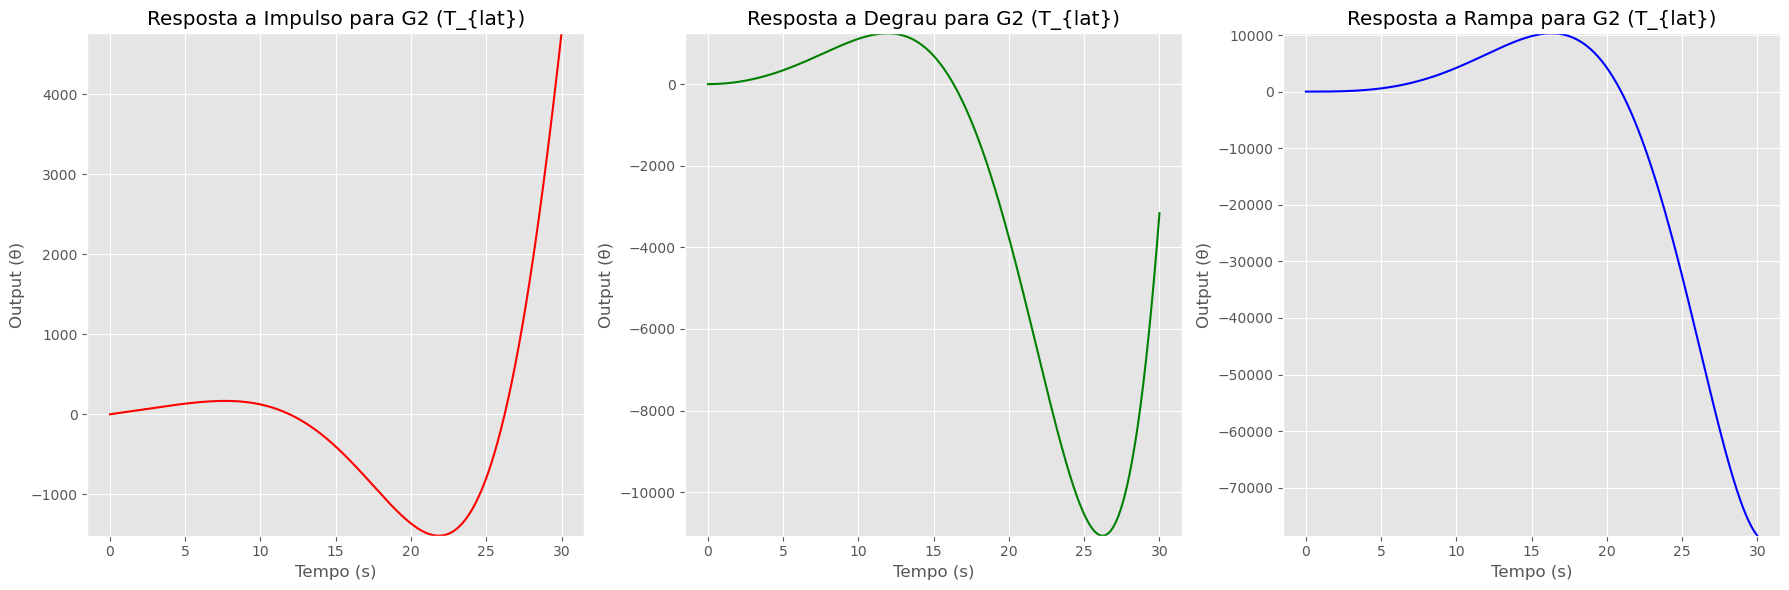

In [43]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(impulseG2.time, impulseG2.outputs, color='red')
plt.title("Resposta a Impulso para G2 (T_{lat})")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (θ)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.subplot(1, 3, 2)
plt.plot(stepG2.time, stepG2.outputs, color='green')
plt.title("Resposta a Degrau para G2 (T_{lat})")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (θ)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.subplot(1, 3, 3)
plt.plot(rampG2.time, rampG2.outputs, color='blue')
plt.title("Resposta a Rampa para G2 (T_{lat})")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (θ)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.tight_layout()
plt.show()

Resposta no Tempo para entradas padrão em $G_3(s)$

In [44]:
stepG3 = ct.step_response(T3, np.linspace(0, 30, 500))
impulseG3 = ct.impulse_response(T3, np.linspace(0, 30, 500))
time_vector = np.linspace(0, 30, 500)
ramp_input = time_vector
rampG3 = ct.forced_response(T3, time_vector, ramp_input)

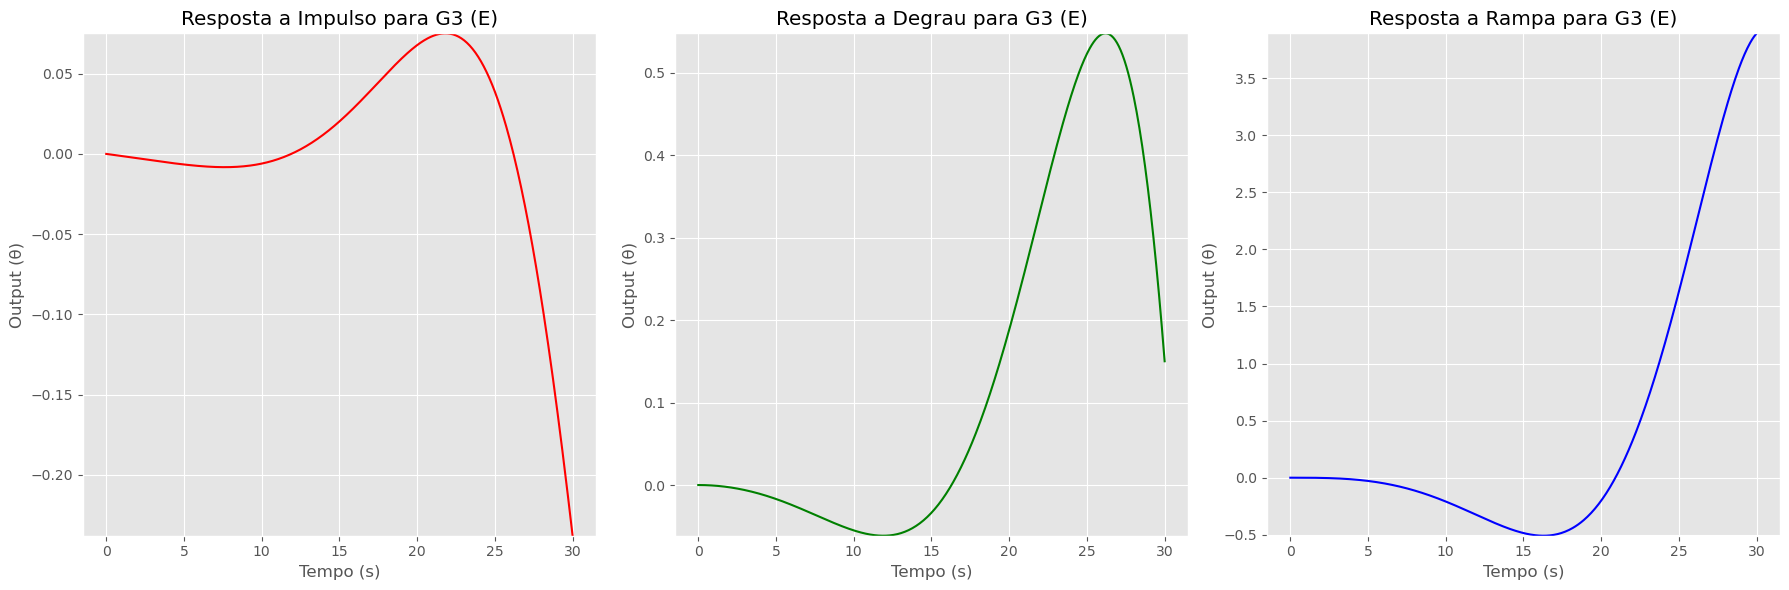

In [45]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(impulseG3.time, impulseG3.outputs, color='red')
plt.title("Resposta a Impulso para G3 (E)")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (θ)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.subplot(1, 3, 2)
plt.plot(stepG3.time, stepG3.outputs, color='green')
plt.title("Resposta a Degrau para G3 (E)")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (θ)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.subplot(1, 3, 3)
plt.plot(rampG3.time, rampG3.outputs, color='blue')
plt.title("Resposta a Rampa para G3 (E)")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (θ)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.tight_layout()
plt.show()

### Simulações Numéricas
Simulações com condição inicial de $\dot y = 240 m/s$ e demais componentes zeradas, de forma a avaliar o efeito do vento sobre o foguete nos dois modelos possíveis, permitindo uma validação do modelo linearizado

Simulação Não Linearizada

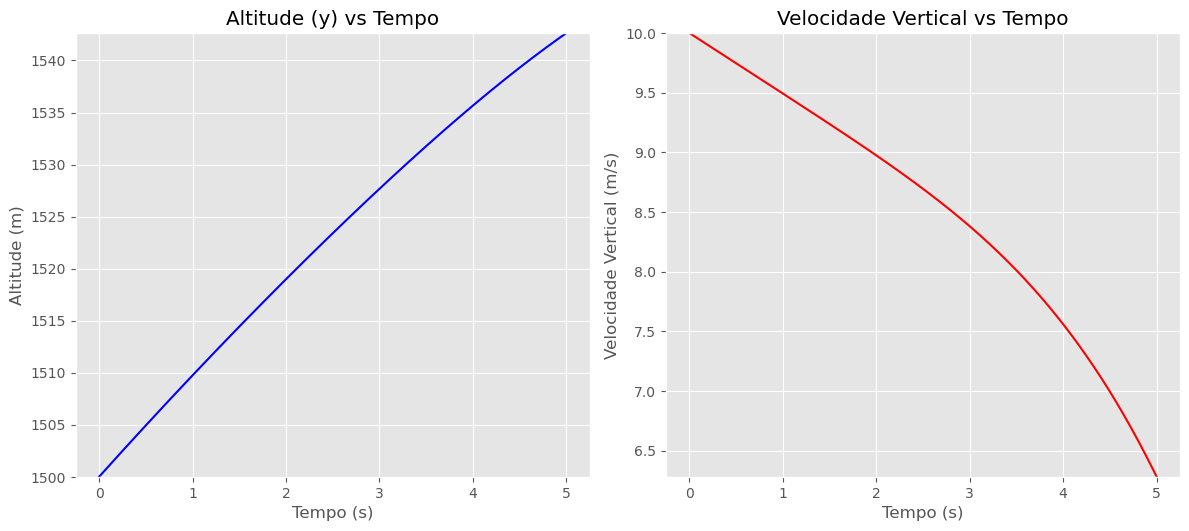

In [46]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

m = 27.0
T = T_eq[0]
Jg = 12.622
A_f = 0.021
A_m = 0.021
g = 9.81
rho = 1.225
D_Cp = 0.381
Cl = 1.5
Cd = 0.35
w = 6

# Definição das Equações Diferenciais
def dxdt(t, x):
    x, y, theta, vx, vy, omega = x

    if abs(vy) < 1e-3:
        vy = 1e-3

    vx_rel = vx - w
    vy_rel = vy
    v_sq = vx_rel**2 + vy_rel**2

    phi = np.pi/2 - np.arctan2(vx_rel, vy_rel)
    alpha = phi - theta

    D = 0.5 * rho * A_f * v_sq * Cd
    L = 0.5 * rho * A_m * v_sq * Cl * abs(alpha)

    fx = -L * np.cos(phi) - D * np.cos(phi) + T * np.cos(theta)
    ax = fx / m

    fy = L * np.sin(phi+np.pi) - D * np.sin(phi) + T * np.sin(theta) - m * g
    ay = fy / m

    torque = L * D_Cp * np.cos(alpha+np.pi) - D * D_Cp * np.sin(alpha)
    acc_theta = torque / Jg

    return [vx, vy, omega, ax, ay, acc_theta]

# Condições Iniciais
y0 = [0, 1500, np.pi/2, 0, V0, 0]

# Tempo de simulação (0 a 20 segundos)
t_span = (0, 5)
t_eval = np.linspace(0, 5, 500)

sol = solve_ivp(dxdt, t_span, y0, t_eval=t_eval, method='RK45')

# Visualização dos Resultados
plt.figure(figsize=(12, 10))

# Altitude
plt.subplot(2, 2, 1)
plt.plot(sol.t, sol.y[1], color='blue')
plt.title("Altitude (y) vs Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Altitude (m)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.subplot(2, 2, 2)
plt.plot(sol.t, sol.y[4], color='red')
plt.title("Velocidade Vertical vs Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Velocidade Vertical (m/s)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.tight_layout()
plt.show()

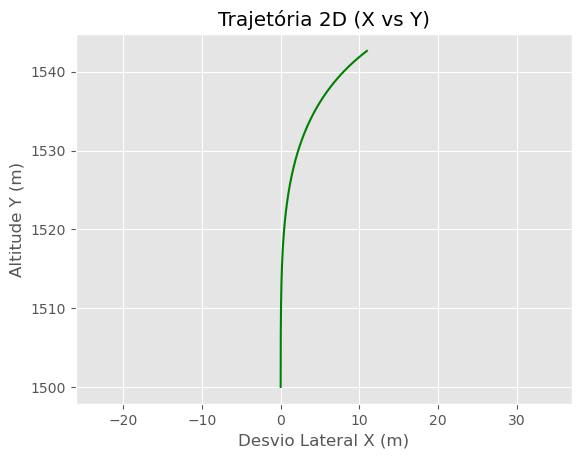

In [47]:
plt.plot(sol.y[0], sol.y[1], color='green')
plt.title("Trajetória 2D (X vs Y)")
plt.xlabel("Desvio Lateral X (m)")
plt.ylabel("Altitude Y (m)")
plt.axis('equal')
plt.grid(True)

Simulação do Sistema Linear

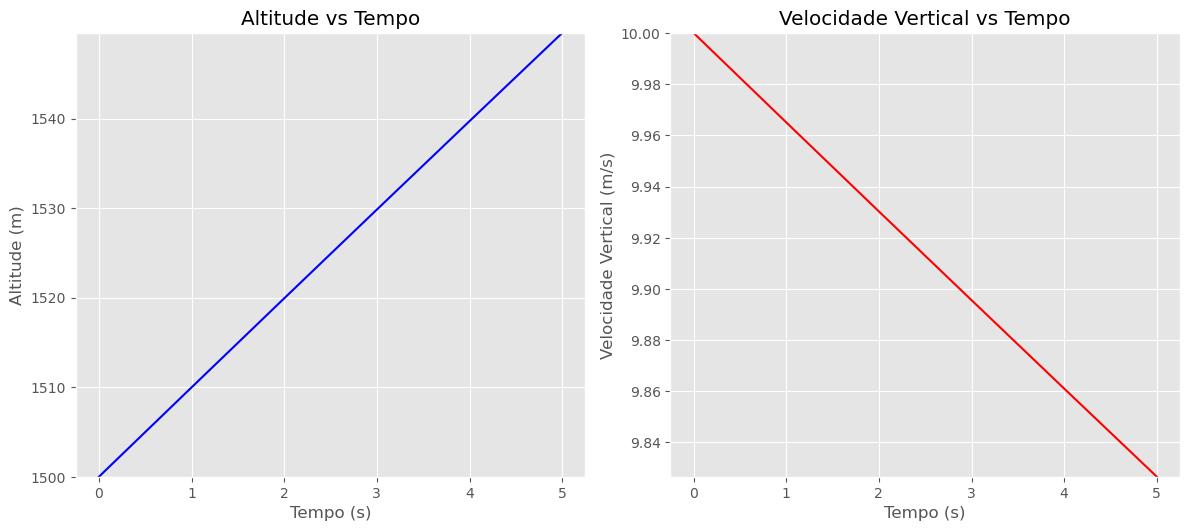

In [48]:
A_np = np.array(A)
B_np = np.array(B).astype(np.float64)
E_np = np.array(E).astype(np.float64)
deltaCd = 0
deltaw = 0
deltaT = 0
def lindxdt(t, x):
    BdCd = (B_np * deltaCd).flatten()
    Edw = (E_np * deltaw).flatten()
    dxdt = A_np@x #+ BdCd + Edw
    return dxdt.flatten()


y0 = [1500, 0, 0, V0, 0]

# Tempo de simulação (0 a 20 segundos)
t_span = (0, 5)
t_eval = np.linspace(0, 5, 500) # Pontos para o gráfico
A_np = np.array(A)
# 4. Execução (Integração Numérica)
sol_lin = solve_ivp(lindxdt, t_span, y0, t_eval=t_eval, method='RK45')

# 5. Visualização dos Resultados (Atualizando títulos para refletir variáveis incrementais)
plt.figure(figsize=(12, 10))

# Desvio Lateral Y Incremental
plt.subplot(2, 2, 1)
plt.plot(sol_lin.t, sol_lin.y[0], color='blue')
plt.title("Altitude vs Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Altitude (m)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.subplot(2, 2, 2)
plt.plot(sol_lin.t, sol_lin.y[3], color='red')
plt.title("Velocidade Vertical vs Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Velocidade Vertical (m/s)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.tight_layout()
plt.show()

(1500.0, 1549.5651753928573)

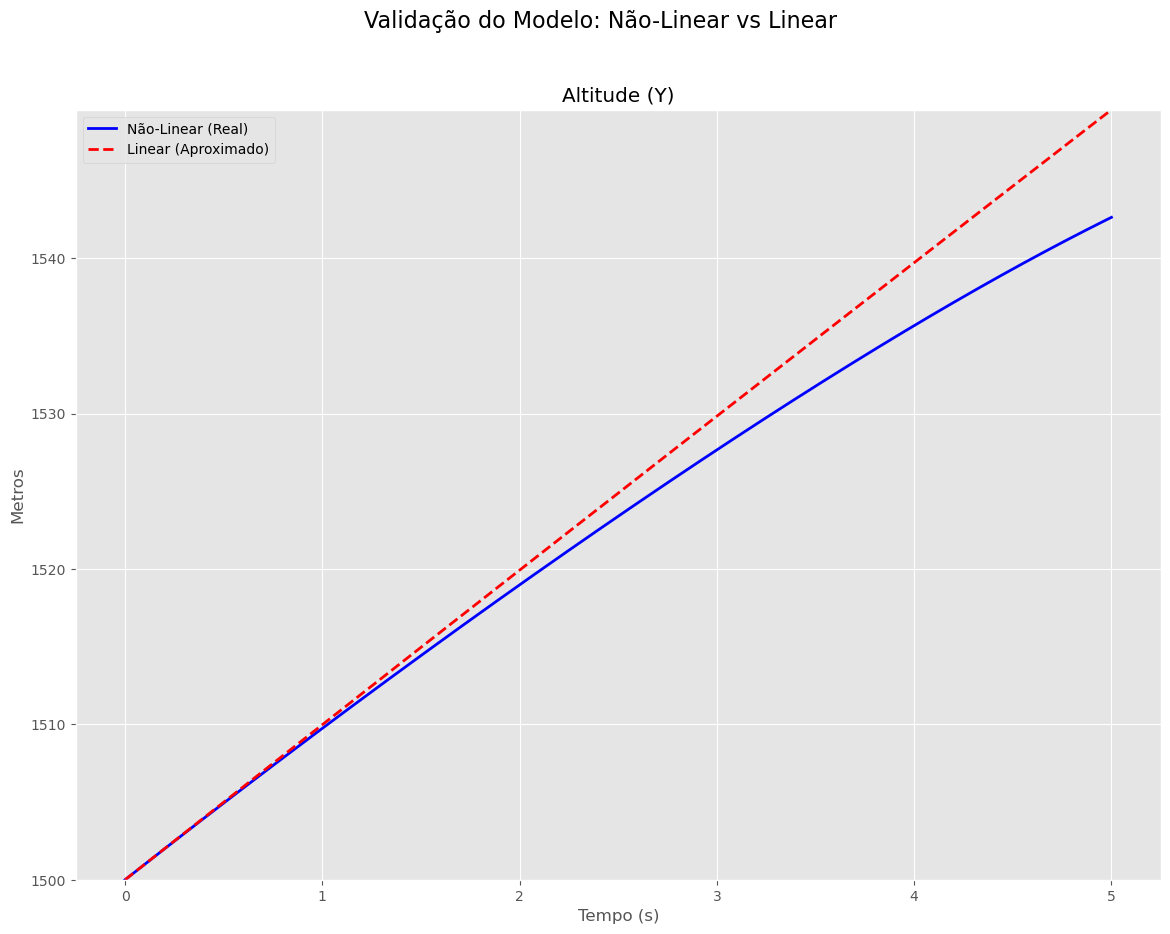

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
fig.suptitle("Validação do Modelo: Não-Linear vs Linear", fontsize=16)

# Non-linear altitude
altitude_nonlinear = sol.y[1]

# Linear altitude (add initial equilibrium altitude to incremental change)
altitude_linear_absolute = sol_lin.y[0]

ax.plot(sol.t, altitude_nonlinear, 'b-', label='Não-Linear (Real)', linewidth=2)
ax.plot(sol_lin.t, altitude_linear_absolute, 'r--', label='Linear (Aproximado)', linewidth=2)

ax.set_title("Altitude (Y)")
ax.set_ylabel("Metros")
ax.set_xlabel("Tempo (s)")
ax.legend()
ax.grid(True)

# Calculate common y-limits for both plots
min_y = min(np.min(altitude_nonlinear), np.min(altitude_linear_absolute))
max_y = max(np.max(altitude_nonlinear), np.max(altitude_linear_absolute))
ax.set_ylim(min_y, max_y)

A proximidade dos valores para t até ~2s demonstra que o sistema linearizado aproxima devidamente a dinâmica de voo, sendo o grande desvio criado após isso devido a instabilidade intrinseca ao sistema, que demonstra a incapacidade do modelo linear prever completamente o comportamento do foguete.

Além disso, o menor valor final de altitude deve-se pelo fato do modelo dinâmico capturar a força de arrasto como proporcional a $v^2$, enquanto o modelo linear captura como coeficiente constante na matriz $A$.

## Síntese de Regulador

Resposta do sistema não controlado

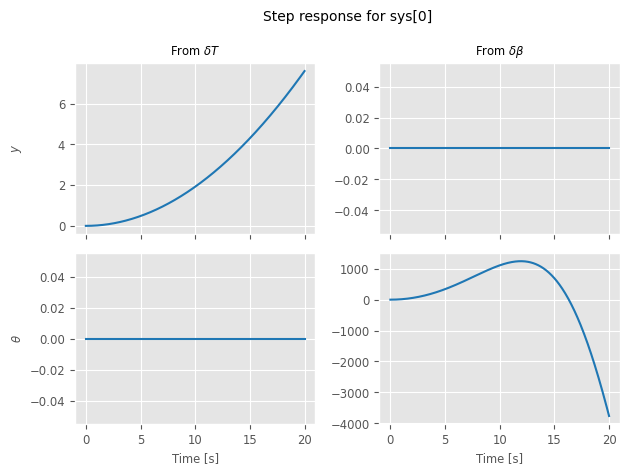

In [50]:
# Atualiza os rótulos do sistema já instanciado
lander.input_labels = [r'$\delta T$', r'$\delta \beta$']
lander.output_labels = [r'$y$', r'$\theta$']

# Plota novamente
ST = ct.step_response(lander, np.linspace(0, 20, 500))
ST.plot()

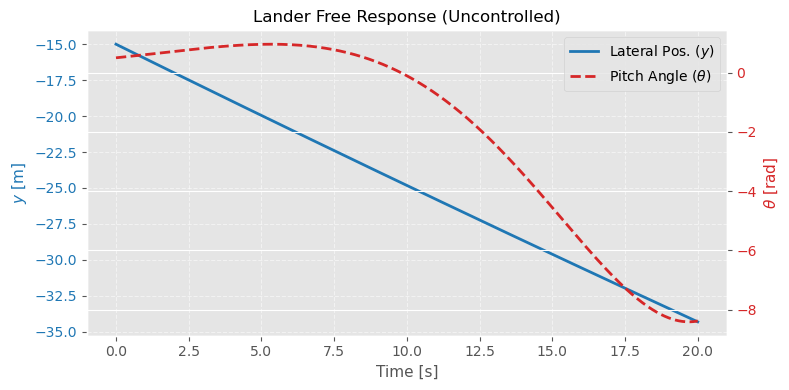

In [51]:

# Definição do tempo e condições iniciais
tsim = np.linspace(0, 20, 1001)
# X0 = [y, theta, x_dot, y_dot, theta_dot]
x0 = [-15, 0.5, 2, -1, 0.1] 

# Como não há controle, você também pode usar ct.initial_response diretamente, 
# mas mantive o forced_response com U=0 para manter sua lógica original.
t_nc, u_nc, x_nc = ct.forced_response(lander, U=0, T=tsim, X0=x0, return_x=True)

# Criação da figura (apenas 1 linha agora, com altura reduzida)
fig, ax_state = plt.subplots(figsize=(8, 4))

# ==========================================
# GRÁFICO: Estados (Com duplo eixo Y)
# ==========================================
color_y = '#1f77b4' # Azul
ax_state.plot(t_nc, x_nc[0, :], color=color_y, linewidth=2, label=r'Lateral Pos. ($y$)')
ax_state.set_ylabel(r'$y$ [m]', color=color_y, fontsize=11)
ax_state.set_xlabel('Time [s]', fontsize=11) # Rótulo de tempo movido para cá
ax_state.tick_params(axis='y', labelcolor=color_y)
ax_state.grid(True, linestyle='--', alpha=0.5)

# Criando o eixo Y secundário para o ângulo
ax_theta = ax_state.twinx()  
color_theta = '#d62728' # Vermelho
ax_theta.plot(t_nc, x_nc[1, :], color=color_theta, linewidth=2, linestyle='--', label=r'Pitch Angle ($\theta$)')
ax_theta.set_ylabel(r'$\theta$ [rad]', color=color_theta, fontsize=11)
ax_theta.tick_params(axis='y', labelcolor=color_theta)

# Juntando as legendas dos dois eixos Y num único quadro
lines_1, labels_1 = ax_state.get_legend_handles_labels()
lines_2, labels_2 = ax_theta.get_legend_handles_labels()
ax_theta.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

# Título do gráfico
ax_state.set_title('Lander Free Response (Uncontrolled)', fontsize=12)

# Ajusta as margens para não cortar os eixos
plt.tight_layout()

# Salva o gráfico em formato vetorial de alta qualidade para o LaTeX
plt.savefig('free_response.pdf', format='pdf', bbox_inches='tight')

plt.show()

### Controlabilidade e Observabilidade

In [52]:
Wc = ct.ctrb(lander.A, lander.B)
rank_Wc = np.linalg.matrix_rank(Wc)


n_est = lander.A.shape[0]

éctr = (rank_Wc == n_est)

print(f"Estados(n): {n_est}")
print(f"Posto da Matriz de Controlabiliade: {rank_Wc}")
print(f"O sistema é totalmente controlável? {éctr}")

Estados(n): 5
Posto da Matriz de Controlabiliade: 5
O sistema é totalmente controlável? True


In [53]:
Cc = ct.ctrb(lander.A.transpose(), lander.C.transpose())
rank_Cc = np.linalg.matrix_rank(Cc)

n_est = lander.A.shape[0]

# 5. Evaluate the result
éobs = (rank_Cc == n_est)

print(f"Estados(n): {n_est}")
print(f"Posto da Matriz de Observabilidade: {rank_Cc}")
print(f"O sistema é totalmente observável? {éobs}")

Estados(n): 5
Posto da Matriz de Observabilidade: 5
O sistema é totalmente observável? True


### Síntese de LQR

In [54]:
Q = np.diag([100, 10000, 1, 100, 10]) #Pune fortemente os estados de posição, ângulo e velocidade vertical, enquanto pune menos as velocidades lateral e angular.
R = np.diag([1, 100]) #Pune o controle lateral, de forma a reduzir o uso do gimble do nozzle, buscando uso somente para ajustes finos.
K_lqr, S, p_lqr = ct.lqr(lander, Q, R)

In [55]:
S

array([[ 2.47925010e+02,  3.17891359e-14, -4.92103837e-14,
         2.57330000e+02, -1.31280756e-14],
       [ 3.17891359e-14,  9.21976946e+02, -8.73223064e+00,
        -1.54651706e-13,  3.38925175e+01],
       [-4.92103837e-14, -8.73223064e+00,  1.01736352e+01,
         1.13620483e-13,  3.30862242e+00],
       [ 2.57330000e+02, -1.54651706e-13,  1.13620483e-13,
         6.35668494e+02,  4.45976084e-14],
       [-1.31280756e-14,  3.38925175e+01,  3.30862242e+00,
         4.45976084e-14,  4.43344979e+00]])

In [56]:
p_lqr

array([ -0.48172582 +0.39565933j,  -0.48172582 -0.39565933j,
       -12.44474425+10.83071807j, -12.44474425-10.83071807j,
        -0.09823324 +0.j        ])

In [57]:
lander_lqr = ct.ss(lander.A - lander.B @ K_lqr, B, lander.C, sp.zeros(2, 2))

c:\Users\felip\anaconda3\Lib\site-packages\control\pzmap.py:381: UserWarning: axis already exists; grid keyword ignored
  warnings.warn("axis already exists; grid keyword ignored")


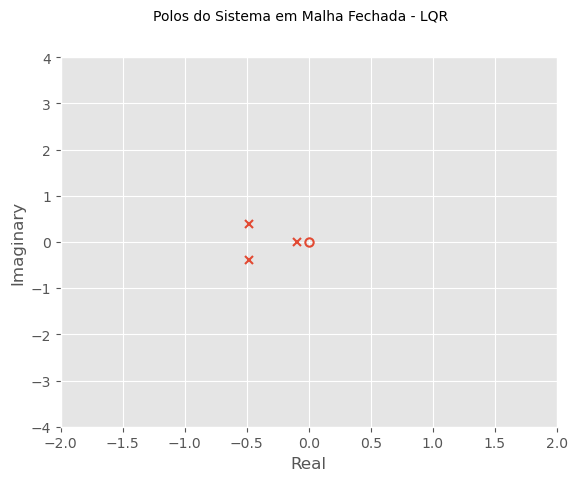

In [58]:
fig, ax = plt.subplots()
ct.pzmap(lander_lqr, title='Polos do Sistema em Malha Fechada - LQR', grid=True)
ax.set_aspect('auto')
plt.xlim([-2, 2])
plt.ylim([-4, 4])
plt.ylabel('Imaginary')
plt.xlabel('Real')
plt.show()

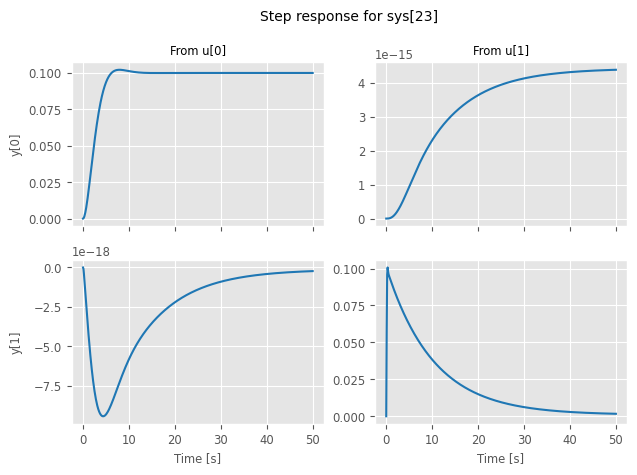

In [59]:
ST_lqr = ct.step_response(lander_lqr, np.linspace(0, 50, 500))
ST_lqr.plot()

### Alocação de Polos

A partir dos polos obtidos no LQR, deseja-se melhorar a resposta, principalmente quanto a entrada de TVC, buscando um transiente com melhores oscilações, aumentando seu amortecimento.

In [60]:
p_lqr

array([ -0.48172582 +0.39565933j,  -0.48172582 -0.39565933j,
       -12.44474425+10.83071807j, -12.44474425-10.83071807j,
        -0.09823324 +0.j        ])

In [61]:
K_aloc = ct.place(lander.A, lander.B, [-0.8+2j, -0.8-2j, -0.7+0.37j, -0.7-0.37j, -1] )

In [62]:
lander_loc = ct.ss(lander.A - lander.B @ K_aloc, B, lander.C, sp.zeros(2, 2))

c:\Users\felip\anaconda3\Lib\site-packages\control\pzmap.py:381: UserWarning: axis already exists; grid keyword ignored
  warnings.warn("axis already exists; grid keyword ignored")


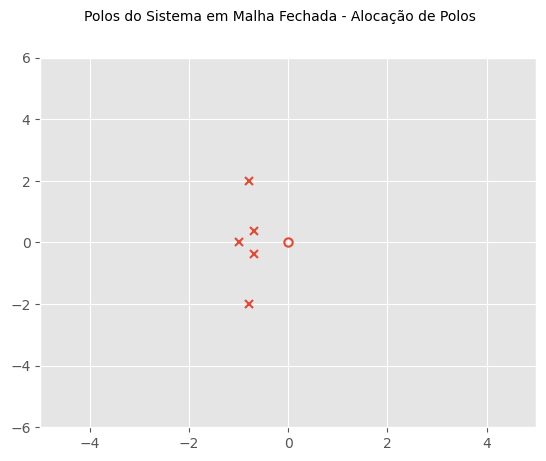

In [63]:
fig, ax = plt.subplots()
ct.pzmap(lander_loc, title='Polos do Sistema em Malha Fechada - Alocação de Polos', grid=True)
ax.set_aspect('auto')
plt.xlim([-5, 5])
plt.ylim([-6, 6])

plt.show()

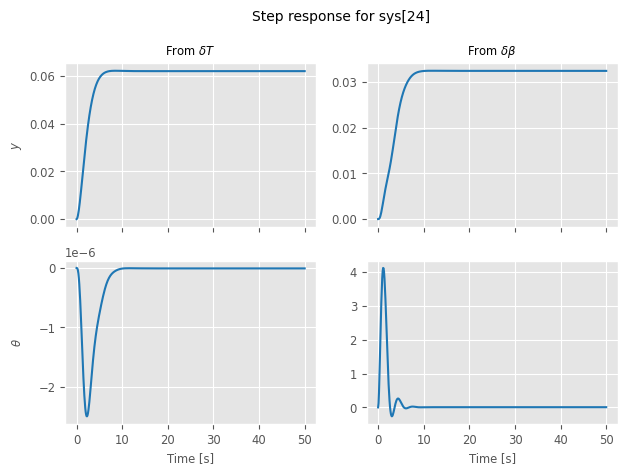

In [64]:
lander_loc.input_labels = [r'$\delta T$', r'$\delta \beta$']
lander_loc.output_labels = [r'$y$', r'$\theta$']
ST_loc = ct.step_response(lander_loc, np.linspace(0, 50, 500))
ST_loc.plot()

In [65]:
print(K_aloc)

[[ 1.61320370e+01 -1.08011622e-02  9.06050268e-03  3.59362112e+01
  -4.75145728e-02]
 [ 2.22103224e-05  2.29926579e-01 -1.72504336e-02  1.02175201e-05
   8.92013360e-02]]


### Resposta do Sistema Controlado

In [66]:
lander_CTR_LQR = ct.ss(lander.A - lander.B @ K_lqr, E, -K_lqr, np.zeros((2, 1)))
lander_CTR_ALC = ct.ss(lander.A - lander.B @ K_aloc, E, -K_aloc, np.zeros((2, 1)))

Resposta Via LQR

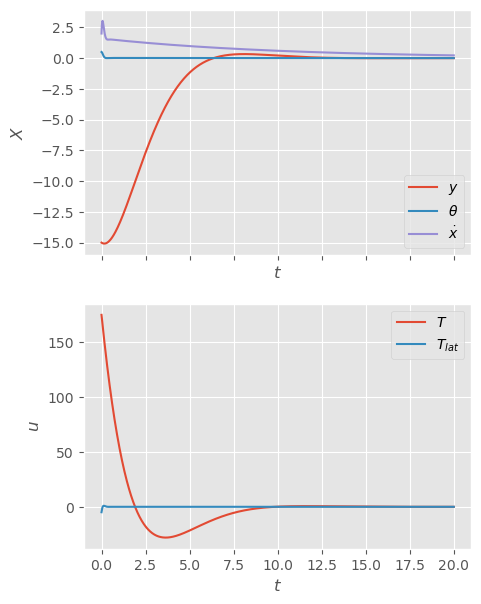

In [67]:
t_lq, u_lq, x_lq = ct.forced_response(lander_CTR_LQR, U=0, T=tsim, X0=x0, return_x=True)

fig, (state, control_input) = plt.subplots(
    2, 1, figsize=(5, 7), sharex=True)

state.plot(t_lq, x_lq[0, :],label=r'$y$')
state.plot(t_lq, x_lq[1, :], label=r'$\theta$')
state.plot(t_lq, x_lq[2, :], label=r'$\dot x$')
state.set_ylabel(r'$X$')
state.set_xlabel(r'$t$')
state.legend()

control_input.plot(t_lq, u_lq[0],  label=r'$T$')
control_input.set_ylabel(r'$u$')
control_input.set_xlabel(r'$t$')
control_input.plot(t_lq, u_lq[1],  label=r'$T_{lat}$')
control_input.set_ylabel(r'$u$')
control_input.set_xlabel(r'$t$')
control_input.legend()

Resposta Via Alocação de Polos

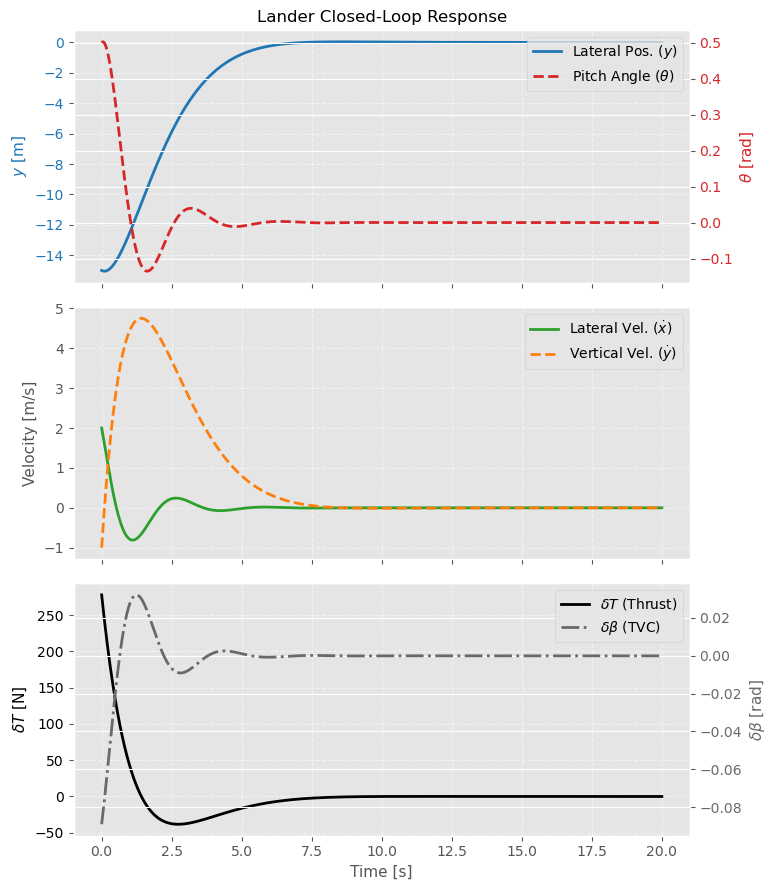

In [68]:

t_aloc, u_aloc, x_aloc = ct.forced_response(lander_CTR_ALC, U=0, T=tsim, X0=x0, return_x=True)

# Criando a figura com 3 subplots (Posição/Atitude, Velocidades, Controle)
fig, (ax_pos, ax_vel, ax_ctrl) = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

# ==========================================
# 1. GRÁFICO: Posição e Atitude (Eixo Duplo)
# ==========================================
color_y = '#1f77b4' # Azul
ax_pos.plot(t_aloc, x_aloc[0, :], color=color_y, linewidth=2, label=r'Lateral Pos. ($y$)')
ax_pos.set_ylabel(r'$y$ [m]', color=color_y, fontsize=11)
ax_pos.tick_params(axis='y', labelcolor=color_y)
ax_pos.grid(True, linestyle='--', alpha=0.5)

ax_theta = ax_pos.twinx()
color_theta = '#d62728' # Vermelho
ax_theta.plot(t_aloc, x_aloc[1, :], color=color_theta, linewidth=2, linestyle='--', label=r'Pitch Angle ($\theta$)')
ax_theta.set_ylabel(r'$\theta$ [rad]', color=color_theta, fontsize=11)
ax_theta.tick_params(axis='y', labelcolor=color_theta)

lines_1, labels_1 = ax_pos.get_legend_handles_labels()
lines_2, labels_2 = ax_theta.get_legend_handles_labels()
ax_theta.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

ax_pos.set_title('Lander Closed-Loop Response', fontsize=12)

# ==========================================
# 2. GRÁFICO: Velocidades (Eixo Único)
# ==========================================
# Como ambas são m/s, podem compartilhar o mesmo eixo
ax_vel.plot(t_aloc, x_aloc[2, :], color='#2ca02c', linewidth=2, label=r'Lateral Vel. ($\dot{x}$)')
ax_vel.plot(t_aloc, x_aloc[3, :], color='#ff7f0e', linewidth=2, linestyle='--', label=r'Vertical Vel. ($\dot{y}$)')
ax_vel.set_ylabel('Velocity [m/s]', fontsize=11)
ax_vel.grid(True, linestyle='--', alpha=0.5)
ax_vel.legend(loc='best')

# ==========================================
# 3. GRÁFICO: Esforço de Controle (Eixo Duplo)
# ==========================================
color_T = 'black'
ax_ctrl.plot(t_aloc, u_aloc[0, :], color=color_T, linewidth=2, label=r'$\delta T$ (Thrust)')
ax_ctrl.set_ylabel(r'$\delta T$ [N]', color=color_T, fontsize=11)
ax_ctrl.tick_params(axis='y', labelcolor=color_T)
ax_ctrl.set_xlabel('Time [s]', fontsize=11)
ax_ctrl.grid(True, linestyle='--', alpha=0.5)

ax_beta = ax_ctrl.twinx()
color_beta = 'dimgrey'
ax_beta.plot(t_aloc, u_aloc[1, :], color=color_beta, linewidth=2, linestyle='-.', label=r'$\delta \beta$ (TVC)')
ax_beta.set_ylabel(r'$\delta \beta$ [rad]', color=color_beta, fontsize=11)
ax_beta.tick_params(axis='y', labelcolor=color_beta)

lines_3, labels_3 = ax_ctrl.get_legend_handles_labels()
lines_4, labels_4 = ax_beta.get_legend_handles_labels()
ax_beta.legend(lines_3 + lines_4, labels_3 + labels_4, loc='best')

# ==========================================
# Finalização e Exportação
# ==========================================
plt.tight_layout()
plt.savefig('closed_loop_response.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Síntese de Observador

In [69]:
T = np.eye(5)#[::-1]  # ou no caso mais geral, use V = la.null_space(C).T
V = T[2:5,]
C = T[0:2,]
M = T.transpose()[:, 0:2]
N = T.transpose()[:, 2:5]

A11 = C @ A @ M
A12 = C @ A @ N
A21 = V @ A @ M
A22 = V @ A @ N

In [70]:
Bo1 = T[0:2,] @ B
Bo2 = T[2:5,] @ B

In [71]:
Obs2 = ct.obsv(A22, A12)
rank_obs2 = np.linalg.matrix_rank(Obs2)
print("--- Observabilidade de (A22, A12) ---")
print("Rank:", rank_obs2)

--- Observabilidade de (A22, A12) ---
Rank: 3


In [72]:
lander_loc.poles()

array([-0.8+2.j  , -0.8-2.j  , -0.7+0.37j, -0.7-0.37j, -1. +0.j  ])

In [73]:
J = (ct.place(A22.T, A12.T, [-6, -10 + 1j, -10 -1j])).T
J

array([[ 2.62837191e+03,  2.69538278e+04],
       [ 9.91085850e+00, -4.10241346e-01],
       [ 1.56823211e+00,  1.60838931e+01]])

In [74]:
F = A22 - J @ A12
G = A21  - J @ A11 + F @ J
H = Bo2 - J @ Bo1
S = M + N @ J

In [75]:
Aa = np.block([[A, np.zeros((5, 5-2))],
          [G @ C, F]])
Ba = np.block([[B], [H]])
Ea = np.block([[E], [np.zeros((5-2, 1))]])
Ca = np.block([[C, np.zeros((2, 5-2))]])

In [76]:
Aa_c = Aa - (Ba @ K_aloc @ np.block([S @ C, N]))
Aa_c

array([[0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [-444.208091824624, -4562.91150350712, -0.00174945595150196, 0, 0,
        -0.169528541984289, 0.000100412622768115, 0.876625644717561],
       [-15.3899894377134, -8.88733100267492, 0, -0.00349891190300392, 0,
        -0.000352096633971294, -1.39650298106290, 0.00184644514025546],
       [1230.69309201677, 12614.4912002860, 0.00225755313800152, 0, 0,
        0.469684387474216, -0.000278196465724882, -2.42872010909830],
       [-68768.0866394769, -437054.284609749, 0, 0, 0,
        -0.171277997935790, -2628.37180995740, -26952.9511467466],
       [-113.006429206979, 1.77822629324334, 0, 0, 0,
        -0.000352096633971294, -11.3108603926454, 0.412087791104967],
       [1195.86097703274, 12417.2926341103, 0, 0, 0, 0.471941940612218,
        -1.56851030789363, -18.5126132415643]], dtype=object)

In [77]:
lander_Obs = ct.ss(Aa_c, Ea, -K_aloc @ np.block([S @ C, N]), np.zeros((2, 1)))

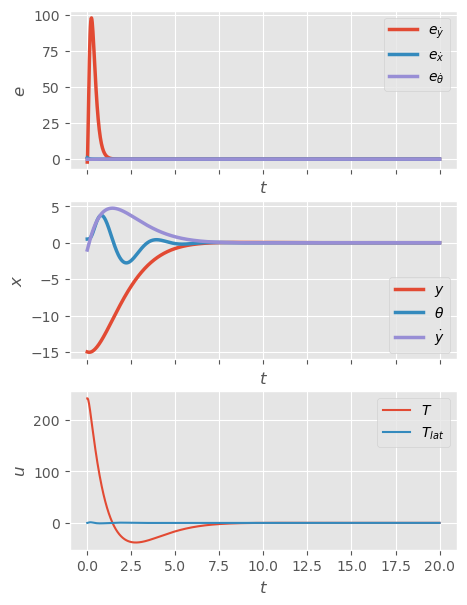

In [78]:
z0 = [0, 0, 0] - J @ C @ x0
t_obs, u_obs, x_obs = ct.forced_response(lander_Obs, U=0, T=tsim, X0=np.append(x0, z0), return_x=True)
xe = S @ C @ x_obs[0:5, :] + N @ x_obs[5:, :]

fig, (errors, state, control_input) = plt.subplots(
    3, 1, figsize=(5, 7), sharex=True)

errors.plot(t_obs, xe[2, :] - x_obs[2, :], linewidth=2.5,
           label=r'$e_{\dot y}$')
errors.plot(t_obs, xe[3, :] - x_obs[3, :], linewidth=2.5,
            label=r'$e_{\dot x}$')
errors.plot(t_obs, xe[4, :] - x_obs[4, :], linewidth=2.5,
            label=r'$e_{\dot \theta}$')
errors.set_ylabel(r'$e$')
errors.set_xlabel(r'$t$')
errors.legend()

state.plot(t_obs, x_obs[0, :], linewidth=2.5,
           label=r'${y}$')
state.plot(t_obs, x_obs[1, :], linewidth=2.5,
           label=r'${\theta}$')
state.plot(t_obs, x_obs[3, :], linewidth=2.5,
           label=r'${\dot y}$')
state.set_ylabel(r'$x$')
state.set_xlabel(r'$t$')
state.legend()

control_input.plot(t_obs, u_obs[0],  label=r'$T$')
control_input.set_ylabel(r'$u$')
control_input.set_xlabel(r'$t$')
control_input.plot(t_obs, u_obs[1],  label=r'$T_{lat}$')
control_input.set_ylabel(r'$u$')
control_input.set_xlabel(r'$t$')
control_input.legend()

## Pré Alimentação via Modelos Assumidos

Aqui define-se um modelo para seguidor de referência, afim de que seja possível manipular o comportamento do foguete quanto a sua trajetória, além de verificar sua capacidade de rejeição de perturbações. A trajetória aqui assumida será a altitude em uma função do tipo seno, buscando aproximar um comportamento de subida/decolagem e descida/pouso, e uma velocidade lateral constante.

In [79]:
ω_s = np.pi/25        # [rad/s]
ζ_s = 0

Ar = np.array([[0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [-ω_s ** 2, 0, 0, -2 * ζ_s * ω_s, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]])



In [80]:
# seleção de variável para seguir referência
M_ref = np.array([
    [1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0]
]).astype(np.float64)

# inversa da matriz de estados em MF
A_cl_inv = np.linalg.inv(Aa_c.astype(np.float64))

# ganho de pré-alimentação
termo_inverso = np.linalg.inv(M_ref @ A_cl_inv @ Ba.astype(np.float64))
Ns = termo_inverso @ M_ref @ A_cl_inv
G_r = Ns @ (Aa.astype(np.float64) - Ar)

In [81]:
K_co = K_aloc @ np.block([S @ C, N])
A_ex_cl = np.block([[Aa - Ba @ K_co , Ba @ (K_co  - G_r)],
                    [np.zeros((8, 8)), Ar]])
E_ex_cl = np.block([[Ea], [np.zeros((8, 1))]])
K_ex = np.block([[-K_co, K_co - G_r]])

# forma de espaço de estados
lander_Seg = ct.ss(A_ex_cl, E_ex_cl, K_ex, 0)
lander_Seg

StateSpace(
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-4.44208092e+02, -4.56291150e+03, -1.74945595e-03,
         0.00000000e+00,  0.00000000e+00, -1.69528542e-01,
         1.00412623e-04,  8.76625645e-01, -3.33423376e-04,
        -4.02212441e-11,  1.70557681e-01,  2.55142671e-05,
         0.00000000e+00,  1.70479855e-16,  2.83881590e-14,
         2.13727185e-12],
       [-1.53899894e+01, 

In [82]:
# Parâmetros
v_xr = 0 # [m/s] constante
amp_y = 50.0
v0_yr = amp_y * ω_s

# [yr, theta_r, vx_r, vy_r, vtheta_r, z1, z2, z3]
x0_seg = np.array([0, 0, 0, 0, 0])
xr0 = np.array([0.0, 0.0, v_xr, v0_yr, 0.0, 0.0, 0.0, 0.0])
y0_medido = C @ x0_seg
z0 = np.array([0.0, 0.0, 0.0]) - J @ y0_medido

Xi = np.concatenate((x0_seg, z0, xr0))

# Simulação
tsim = np.linspace(0, 25, 1001)
tss, u, x_sims = ct.forced_response(lander_Seg, U=0, T=tsim, X0=Xi, return_x=True)

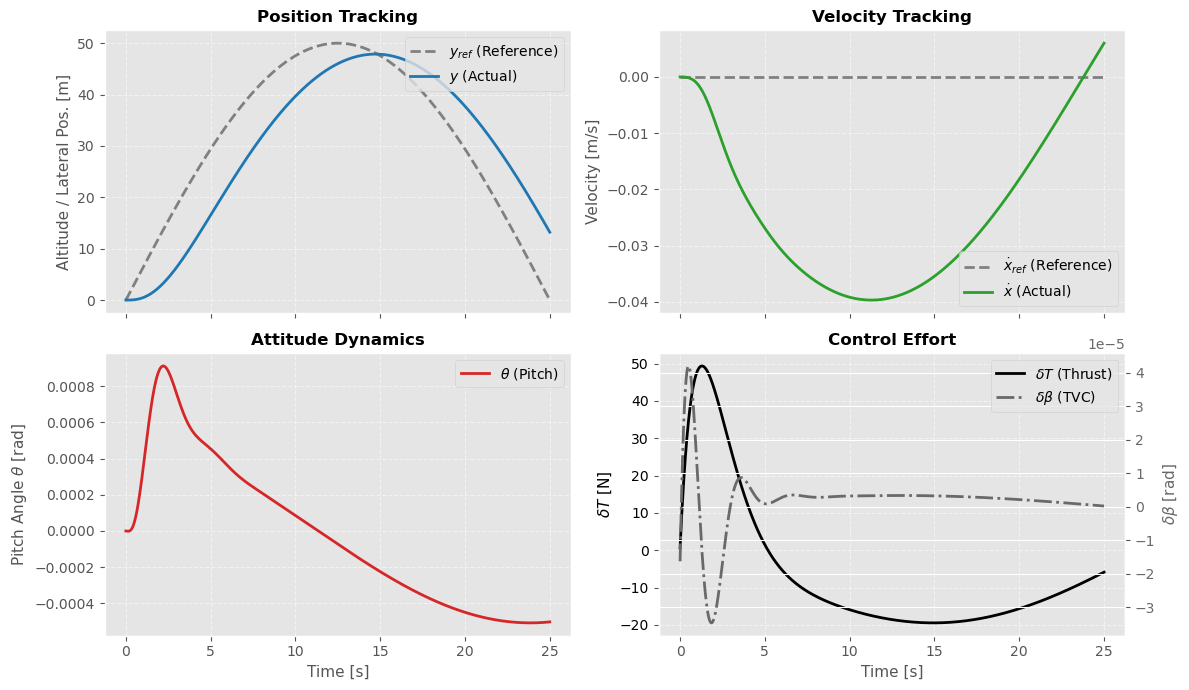

In [83]:

fig, ((ax_alt, ax_vel), (ax_att, ax_ctrl)) = plt.subplots(2, 2, figsize=(12, 7), sharex='col')

# ==========================================
# Gráfico 1: Posição (Rastreamento)
# ==========================================
ax_alt.plot(tss, x_sims[8, :], color='gray', linestyle='--', linewidth=2, label=r'$y_{ref}$ (Reference)')
ax_alt.plot(tss, x_sims[0, :], color='#1f77b4', linewidth=2, label=r'$y$ (Actual)')
ax_alt.set_ylabel(r'Altitude / Lateral Pos. [m]', fontsize=11)
ax_alt.set_title('Position Tracking', fontsize=12, fontweight='bold')
ax_alt.legend(loc='upper right')
ax_alt.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# Gráfico 2: Velocidade (Rastreamento)
# ==========================================
ax_vel.plot(tss, x_sims[10, :], color='gray', linestyle='--', linewidth=2, label=r'$\dot{x}_{ref}$ (Reference)')
ax_vel.plot(tss, x_sims[2, :], color='#2ca02c', linewidth=2, label=r'$\dot{x}$ (Actual)')
ax_vel.set_ylabel(r'Velocity [m/s]', fontsize=11)
ax_vel.set_title('Velocity Tracking', fontsize=12, fontweight='bold')
ax_vel.legend(loc='lower right')
ax_vel.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# Gráfico 3: Atitude
# ==========================================
ax_att.plot(tss, x_sims[1, :], color='#d62728', linewidth=2, label=r'$\theta$ (Pitch)')
ax_att.set_ylabel(r'Pitch Angle $\theta$ [rad]', fontsize=11)
ax_att.set_xlabel(r'Time [s]', fontsize=11)
ax_att.set_title('Attitude Dynamics', fontsize=12, fontweight='bold')
ax_att.legend(loc='upper right')
ax_att.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# Gráfico 4: Esforço de Controle (Eixo Duplo)
# ==========================================
# Eixo principal (Esquerda): Empuxo
color_T = 'black'
ax_ctrl.plot(tss, u[0, :], color=color_T, linewidth=2, label=r'$\delta T$ (Thrust)')
ax_ctrl.set_ylabel(r'$\delta T$ [N]', color=color_T, fontsize=11)
ax_ctrl.tick_params(axis='y', labelcolor=color_T)
ax_ctrl.set_xlabel(r'Time [s]', fontsize=11)
ax_ctrl.set_title('Control Effort', fontsize=12, fontweight='bold')
ax_ctrl.grid(True, linestyle='--', alpha=0.5)

# Eixo secundário (Direita): Deflexão do TVC
ax_beta = ax_ctrl.twinx()
color_beta = 'dimgrey'
ax_beta.plot(tss, u[1, :], color=color_beta, linestyle='-.', linewidth=2, label=r'$\delta \beta$ (TVC)')
ax_beta.set_ylabel(r'$\delta \beta$ [rad]', color=color_beta, fontsize=11)
ax_beta.tick_params(axis='y', labelcolor=color_beta)

# Unificando legendas do painel de controle
lines_3, labels_3 = ax_ctrl.get_legend_handles_labels()
lines_4, labels_4 = ax_beta.get_legend_handles_labels()
ax_beta.legend(lines_3 + lines_4, labels_3 + labels_4, loc='best')

# ==========================================
# Finalização
# ==========================================
plt.tight_layout()
plt.savefig('tracking_performance.pdf', format='pdf', bbox_inches='tight')
plt.show()

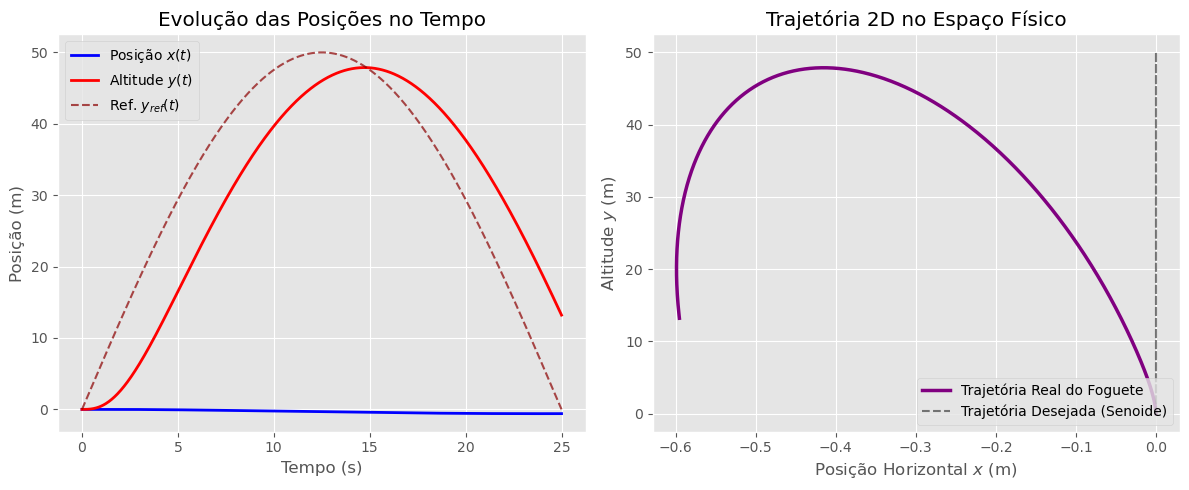

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid


# 1. Recuperando as variáveis para o plot
# y real é o estado 0. y de referência é o estado 8 (no sistema aumentado).
y_pos = x_sims[0, :]
y_ref = x_sims[8, :]

# v_x real é o estado 2. v_x de referência é o estado 10.
vx_real = x_sims[2, :]
vx_ref = x_sims[10, :]

# 2. Integrando as velocidades para obter a posição horizontal x(t)
x_pos = cumulative_trapezoid(vx_real, tss, initial=0.0)
x_ref = cumulative_trapezoid(vx_ref, tss, initial=0.0)

# 3. Plotagem Especial da Trajetória
fig_traj, (ax_time, ax_xy) = plt.subplots(1, 2, figsize=(12, 5))

# --- GRÁFICO 1: Posições vs Tempo ---
ax_time.plot(tss, x_pos, label=r'Posição $x(t)$', color='blue', linewidth=2)
ax_time.plot(tss, y_pos, label=r'Altitude $y(t)$', color='red', linewidth=2)
ax_time.plot(tss, y_ref, '--', label=r'Ref. $y_{ref}(t)$', color='darkred', alpha=0.7)
ax_time.set_xlabel('Tempo (s)')
ax_time.set_ylabel('Posição (m)')
ax_time.set_title('Evolução das Posições no Tempo')
ax_time.legend(loc='upper left')
ax_time.grid(True)

# --- GRÁFICO 2: Trajetória 2D no Espaço (y vs x) ---
ax_xy.plot(x_pos, y_pos, label='Trajetória Real do Foguete', color='purple', linewidth=2.5)
ax_xy.plot(x_ref, y_ref, '--', label='Trajetória Desejada (Senoide)', color='black', alpha=0.5)

ax_xy.set_xlabel('Posição Horizontal $x$ (m)')
ax_xy.set_ylabel('Altitude $y$ (m)')
ax_xy.set_title('Trajetória 2D no Espaço Físico')
ax_xy.legend(loc='lower right')
ax_xy.grid(True)

plt.tight_layout()
plt.show()

Gerando e salvando o GIF animado com atitude... Aguarde!
Sucesso! Abra o arquivo 'trajetoria_foguete_com_angulo.gif' para ver o voo.


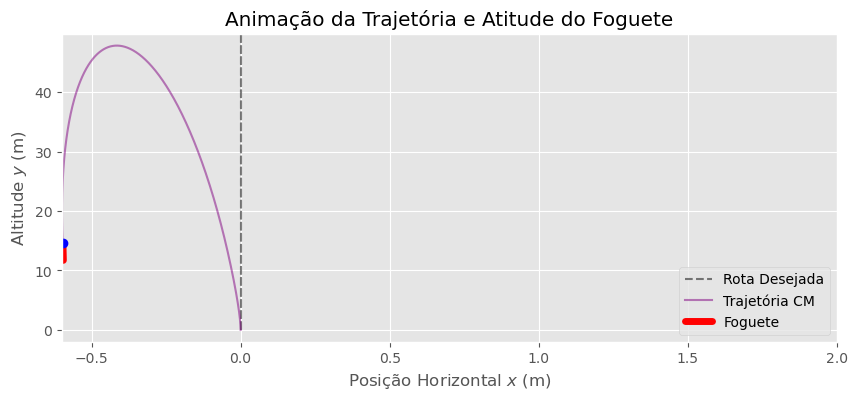

In [85]:
import matplotlib.animation as animation
import numpy as np

# 1. Recuperando o ângulo real do vetor de estados simulado
theta_real = x_sims[1, :]

# Tamanho do foguete no gráfico (em metros). Ajuste para ficar visualmente agradável!
L = 3.0

# 2. Configurando a figura
fig_anim, ax_anim = plt.subplots(figsize=(10, 4))
ax_anim.set_xlim(np.min(x_pos), np.max(x_pos) + 2)
ax_anim.set_ylim(np.min(y_pos) - 2, np.max(y_pos) + 2)

ax_anim.set_xlabel('Posição Horizontal $x$ (m)')
ax_anim.set_ylabel('Altitude $y$ (m)')
ax_anim.set_title('Animação da Trajetória e Atitude do Foguete')
ax_anim.grid(True)

# 3. Criando os objetos gráficos
linha_ref, = ax_anim.plot([], [], '--', color='black', alpha=0.5, label='Rota Desejada')
linha_real, = ax_anim.plot([], [], color='purple', linewidth=1.5, alpha=0.5, label='Trajetória CM')

# O Foguete: Uma linha grossa para o corpo e um ponto para o "bico" (para sabermos onde é a frente)
foguete_corpo, = ax_anim.plot([], [], color='red', linewidth=5, solid_capstyle='round', label='Foguete')
foguete_bico, = ax_anim.plot([], [], 'o', color='blue', markersize=6)

ax_anim.legend(loc='lower right')

def init():
    linha_ref.set_data([], [])
    linha_real.set_data([], [])
    foguete_corpo.set_data([], [])
    foguete_bico.set_data([], [])
    return linha_ref, linha_real, foguete_corpo, foguete_bico

def update(frame):
    # Rastro da trajetória até o frame atual
    linha_ref.set_data(x_ref[:frame], y_ref[:frame])
    linha_real.set_data(x_pos[:frame], y_pos[:frame])

    # Posição do Centro de Massa (CM) e Ângulo no instante atual
    x_cm = x_pos[frame]
    y_cm = y_pos[frame]
    theta = theta_real[frame]

    # Calculando as pontas do bastão com trigonometria
    # (Se o foguete inclinar para o lado errado na animação, basta inverter o sinal de dx)
    dx = (L / 2.0) * np.sin(theta)
    dy = (L / 2.0) * np.cos(theta)

    # Coordenadas da base (motor) e do bico
    x_base = x_cm - dx
    y_base = y_cm - dy
    x_bico = x_cm + dx
    y_bico = y_cm + dy

    # Atualiza o corpo (linha conectando a base ao bico)
    foguete_corpo.set_data([x_base, x_bico], [y_base, y_bico])

    # Atualiza o ponto azul (bico) para mostrar a orientação
    foguete_bico.set_data([x_bico], [y_bico])

    return linha_ref, linha_real, foguete_corpo, foguete_bico

# Pulando frames para renderizar mais rápido (ajuste se quiser mais fluido ou mais leve)
frames_pulados = np.arange(0, len(tss), 4)

ani = animation.FuncAnimation(fig_anim, update, frames=frames_pulados,
                              init_func=init, blit=True, interval=20)

print("Gerando e salvando o GIF animado com atitude... Aguarde!")
ani.save('trajetoria_foguete_com_angulo.gif', writer='pillow', fps=30)
print("Sucesso! Abra o arquivo 'trajetoria_foguete_com_angulo.gif' para ver o voo.")

plt.show()

Simulação em Malha Fechada para Seguidor de Referência sob Perturbação

In [86]:
import numpy as np
import control as ct

tsim = np.linspace(0, 25, 1001)
x0_seg = np.array([0, 0, 0, 0, 0])

y0_medido = C @ x0_seg
z0 = np.array([0.0, 0.0, 0.0]) - J @ y0_medido
xr0 = np.array([0.0, 0.0, v_xr, v0_yr, 0.0, 0.0, 0.0, 0.0])
Xi = np.concatenate((x0_seg, z0, xr0))

# Perfil de vento
w_vento = 3*np.sin(0.5*tsim)

# Simulação com Resposta Forçada
tp, u_sim, x_sim = ct.forced_response(lander_Seg, T=tsim, U=w_vento, X0=Xi, return_x=True)

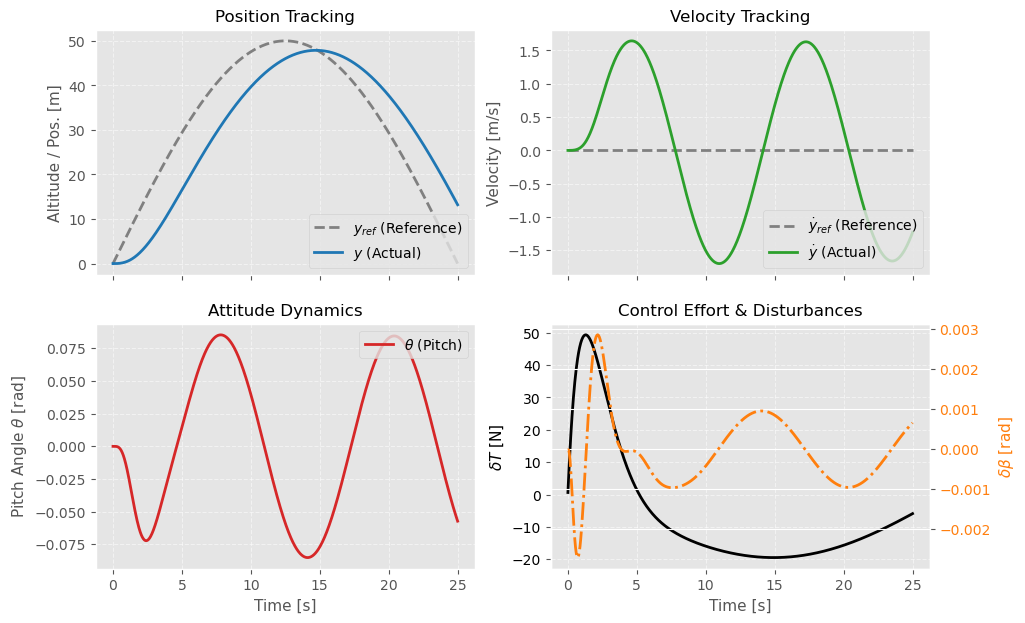

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# Criando a figura com um grid 2x2
fig, ((ax_alt, ax_vel), (ax_att, ax_u)) = plt.subplots(2, 2, figsize=(12, 7), sharex='col')

# ==========================================
# Gráfico 1: Posição (Altitude) [Canto Superior Esquerdo]
# ==========================================
ax_alt.plot(tsim, x_sim[8, :], color='gray', linestyle='--', linewidth=2, label=r'$y_{ref}$ (Reference)')
ax_alt.plot(tsim, x_sim[0, :], color='#1f77b4', linewidth=2, label=r'$y$ (Actual)')
ax_alt.set_ylabel('Altitude / Pos. [m]', fontsize=11)
ax_alt.set_title('Position Tracking', fontsize=12)
ax_alt.legend(loc='lower right')
ax_alt.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# Gráfico 2: Velocidade Horizontal [Canto Superior Direito]
# ==========================================
ax_vel.plot(tsim, x_sim[10, :], color='gray', linestyle='--', linewidth=2, label=r'$\dot{y}_{ref}$ (Reference)')
ax_vel.plot(tsim, x_sim[2, :], color='#2ca02c', linewidth=2, label=r'$\dot{y}$ (Actual)')
ax_vel.set_ylabel('Velocity [m/s]', fontsize=11)
ax_vel.set_title('Velocity Tracking', fontsize=12)
ax_vel.legend(loc='lower right')
ax_vel.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# Gráfico 3: Ângulo [Canto Inferior Esquerdo]
# ==========================================
ax_att.plot(tsim, x_sim[1, :], color='#d62728', linewidth=2, label=r'$\theta$ (Pitch)')
ax_att.set_ylabel(r'Pitch Angle $\theta$ [rad]', fontsize=11)
ax_att.set_xlabel('Time [s]', fontsize=11)
ax_att.set_title('Attitude Dynamics', fontsize=12)
ax_att.legend(loc='upper right')
ax_att.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# Gráfico 4: Esforço de Controle + Vento (TRIPLO EIXO Y)
# ==========================================
ax_u.set_title('Control Effort & Disturbances', fontsize=12)

# Eixo Y Principal (Esquerda): Empuxo (Newtons)
color_T = 'black'
ax_u.plot(tsim, u_sim[0, :], label=r'$\delta T$ (Thrust)', color=color_T, linewidth=2)
ax_u.set_ylabel(r'$\delta T$ [N]', color=color_T, fontsize=11)
ax_u.tick_params(axis='y', labelcolor=color_T)
ax_u.set_xlabel('Time [s]', fontsize=11)
ax_u.grid(True, linestyle='--', alpha=0.5)

# Eixo Y Secundário 1 (Direita Interna): TVC (Radianos)
ax_beta = ax_u.twinx()
color_beta = '#ff7f0e' # Laranja
ax_beta.plot(tsim, u_sim[1, :], label=r'$\delta \beta$ (TVC)', color=color_beta, linestyle='-.', linewidth=2)
ax_beta.set_ylabel(r'$\delta \beta$ [rad]', color=color_beta, fontsize=11)
ax_beta.tick_params(axis='y', labelcolor=color_beta)


# Agrupando as 3 legendas num quadro só
lines_u, labels_u = ax_u.get_legend_handles_labels()
lines_b, labels_b = ax_beta.get_legend_handles_labels()
# Usando o ax_wind para ancorar a legenda combinada

# ==========================================
# Finalização
# ==========================================
# Dá um espaço extra à direita da figura para que o 3º eixo não seja cortado
fig.subplots_adjust(right=0.82) 

# Salva em vetor para o Overleaf (bbox_inches='tight' garante que margens extras sejam incluídas)
plt.savefig('landing_simulation_with_wind.pdf', format='pdf', bbox_inches='tight')
plt.show()

Ressalta-se aqui que há seguimento de referência em altitude e em $\dot x$, não no posicionamento $x$, o que explica o comportamento da trajetória descrita abaixo

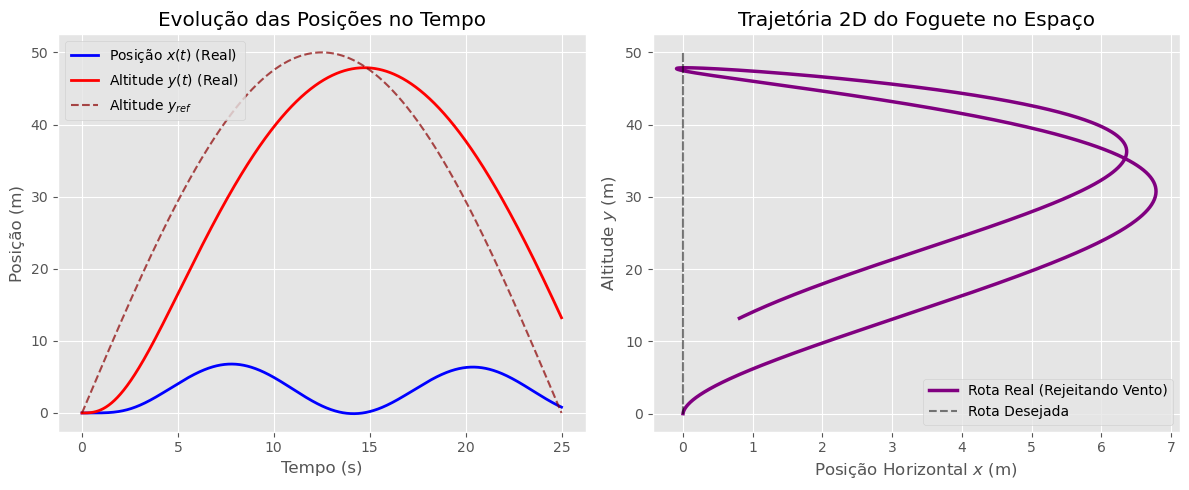

In [89]:
import numpy as np
from scipy.integrate import cumulative_trapezoid

# 1. Recuperando as variáveis da sua simulação com vento
y_pos = x_sim[0, :]
y_ref = x_sim[8, :]

vx_real = x_sim[2, :]
vx_ref = x_sim[10, :]

# 2. Integrando as velocidades no novo vetor de tempo (tsim) para obter a posição x(t)
x_pos = cumulative_trapezoid(vx_real, tsim, initial=0.0)
x_ref = cumulative_trapezoid(vx_ref, tsim, initial=0.0)

# 3. Plotagem da Trajetória 2D
fig_traj, (ax_time, ax_xy) = plt.subplots(1, 2, figsize=(12, 5))

# --- GRÁFICO 1: Evolução das Posições vs Tempo ---
ax_time.plot(tsim, x_pos, label=r'Posição $x(t)$ (Real)', color='blue', linewidth=2)
ax_time.plot(tsim, y_pos, label=r'Altitude $y(t)$ (Real)', color='red', linewidth=2)
ax_time.plot(tsim, y_ref, '--', label=r'Altitude $y_{ref}$', color='darkred', alpha=0.7)
ax_time.set_xlabel('Tempo (s)')
ax_time.set_ylabel('Posição (m)')
ax_time.set_title('Evolução das Posições no Tempo')
ax_time.legend(loc='upper left')
ax_time.grid(True)

# --- GRÁFICO 2: Trajetória 2D no Espaço (y vs x) ---
ax_xy.plot(x_pos, y_pos, label='Rota Real (Rejeitando Vento)', color='purple', linewidth=2.5)
ax_xy.plot(x_ref, y_ref, '--', label='Rota Desejada', color='black', alpha=0.5)

ax_xy.set_xlabel('Posição Horizontal $x$ (m)')
ax_xy.set_ylabel('Altitude $y$ (m)')
ax_xy.set_title('Trajetória 2D do Foguete no Espaço')
ax_xy.legend(loc='lower right')
ax_xy.grid(True)

# Garante que os eixos tenham a mesma proporção (opcional, comente se distorcer muito)
# ax_xy.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

Renderizando e salvando o GIF... Aguarde!
Sucesso! O arquivo 'foguete_com_vento.gif' foi salvo na pasta do seu projeto.


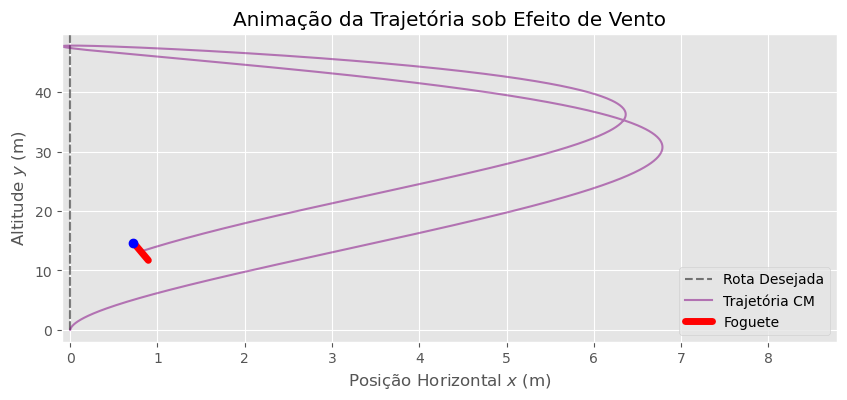

In [90]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import cumulative_trapezoid

# 1. Recuperando os dados do vetor x_sim
y_pos = x_sim[0, :]
y_ref = x_sim[8, :]
vx_real = x_sim[2, :]
vx_ref = x_sim[10, :]
theta_real = x_sim[1, :]

# 2. Integrando a velocidade no tempo (tsim) para obter as posições horizontais x
x_pos = cumulative_trapezoid(vx_real, tsim, initial=0.0)
x_ref = cumulative_trapezoid(vx_ref, tsim, initial=0.0)

# Tamanho visual do foguete no gráfico (em metros)
L = 3.0

# 3. Configurando a figura
fig_anim, ax_anim = plt.subplots(figsize=(10, 4))
ax_anim.set_xlim(np.min(x_pos), np.max(x_pos) + 2)
ax_anim.set_ylim(np.min(y_pos) - 2, np.max(y_pos) + 2)

ax_anim.set_xlabel('Posição Horizontal $x$ (m)')
ax_anim.set_ylabel('Altitude $y$ (m)')
ax_anim.set_title('Animação da Trajetória sob Efeito de Vento')
ax_anim.grid(True)

# 4. Criando os objetos gráficos que serão atualizados
linha_ref, = ax_anim.plot([], [], '--', color='black', alpha=0.5, label='Rota Desejada')
linha_real, = ax_anim.plot([], [], color='purple', linewidth=1.5, alpha=0.5, label='Trajetória CM')

# Foguete (bastão) e o bico (ponto azul para saber a frente)
foguete_corpo, = ax_anim.plot([], [], color='red', linewidth=5, solid_capstyle='round', label='Foguete')
foguete_bico, = ax_anim.plot([], [], 'o', color='blue', markersize=6)

ax_anim.legend(loc='lower right')

# 5. Funções da Animação
def init():
    linha_ref.set_data([], [])
    linha_real.set_data([], [])
    foguete_corpo.set_data([], [])
    foguete_bico.set_data([], [])
    return linha_ref, linha_real, foguete_corpo, foguete_bico

def update(frame):
    # Desenha o rastro até o instante atual
    linha_ref.set_data(x_ref[:frame], y_ref[:frame])
    linha_real.set_data(x_pos[:frame], y_pos[:frame])

    # Coordenadas do Centro de Massa (CM)
    x_cm = x_pos[frame]
    y_cm = y_pos[frame]
    theta = theta_real[frame]

    # Trigonometria para orientar o bastão
    dx = (L / 2.0) * np.sin(theta)
    dy = (L / 2.0) * np.cos(theta)

    x_base = x_cm - dx
    y_base = y_cm - dy
    x_bico = x_cm + dx
    y_bico = y_cm + dy

    # Atualiza a linha e o bico
    foguete_corpo.set_data([x_base, x_bico], [y_base, y_bico])
    foguete_bico.set_data([x_bico], [y_bico])

    return linha_ref, linha_real, foguete_corpo, foguete_bico

# 6. Gerando o GIF
# Pula de 4 em 4 frames para acelerar a renderização (o tsim tem 1001 pontos)
frames_pulados = np.arange(0, len(tsim), 4)

ani = animation.FuncAnimation(fig_anim, update, frames=frames_pulados,
                              init_func=init, blit=True, interval=20)

print("Renderizando e salvando o GIF... Aguarde!")
ani.save('foguete_com_vento.gif', writer='pillow', fps=30)
print("Sucesso! O arquivo 'foguete_com_vento.gif' foi salvo na pasta do seu projeto.")

plt.show()